Title: Contribution_RL_Days_NM_fut.ipynb

Purpose: Look how the different components (wind, solar, demand) contribute to the residual load days

Author: Onno Nennecke on 03.09.2025 Modified: 27.02.2026

Input data: 

- Combined model output: model_output_all_future.nc
    - This file lies here: /climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc

Output data:

- Plot: 
    - This file lies here: /home/onennecke/Code/Figures/

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib import colors, cm
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection

In [2]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'
files = [path]

ds = xr.open_dataset(path)

ts_datasets = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets.load()

# ds_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
# ds_ERA5.load()

# ds_SMARD = ds.where(ds.ESM_run == 'SMARD_hist', drop=True)
# ds_SMARD.load()
# ts_datasets

<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 192, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
  * time           (time) datetime64[ns] 29kB 2039-01-01 ... 2048-12-31
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 1.208 -0.303 ... 6.245 7.776
    demand         (ESM_run, time) float64 6MB 1.505e+03 1.524e+03 ... 1.422e+03
    sfcWind        (ESM_run, time) float64 6MB 4.406 6.058 5.642 ... 6.601 8.858
    rsds           (ESM_run, time) float32 3MB 23.72 30.12 26.28 ... 32.49 20.75
    tas            (ESM_run, time) float32 3MB 1.553 0.233 ... 6.191 7.687
    tasmax         (ESM_run, time) float32 3MB 2.524 1.048 ... 9.226 9.364
    wind_off_prod  (ESM_run, time) float64 6MB 92.24 77.15 30.34 ... 166.3 147.1
    wind_on_prod   (ESM_run, time) float64 6MB 153.1 321.4 ... 539.8 1.166e+03
    solar_prod     (ESM_run, time) float64 6MB 38.47 53.53 46.18 ... 61.05 37.61
    total_prod     (ESM_run, time) float64 6MB 283.8 452.1 ... 767.1 1.351e+03
    Netto          (ESM_run, time) float64 6MB -1.221e+03 -1.072e+03 ... -71.73
    Residual_load  (ESM_run, time) float64 6MB 1.221e+03 1.072e+03 ... 71.73

In [3]:
path_current_clim = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'

ds_curr_clim = xr.open_dataset(path_current_clim)

ts_datasets_curr_clim = ds_curr_clim.where((ds_curr_clim.ESM_run != 'ERA5_hist_wwd') & (ds_curr_clim.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets_curr_clim.load()

res_load = ts_datasets_curr_clim['Residual_load']

res_load_thresh = np.quantile(res_load.values.flatten(), 0.95)

print(res_load_thresh)

1319.138650687668


In [4]:
# --- 2) Extract the three time series arrays [ESM_run, time] ---
# wind = ts_datasets['wind_off_prod'] + ts_datasets['wind_on_prod']
solar = ts_datasets['solar_prod']
total = ts_datasets['total_prod']
# demand = ts_datasets['demand']
res_load = ts_datasets['Residual_load']
wind = ts_datasets['wind_off_prod'] + ts_datasets['wind_on_prod']
# solar = ts_datasets['solar_prod']
# total = ts_datasets['total_prod']
demand = ts_datasets['demand']
# res_load = ts_datasets['Residual_load']

# Thresholds
wind_thresh = np.quantile(wind.values.flatten(), 0.05)
solar_thresh = np.quantile(solar.values.flatten(), 0.05)
total_thresh = np.quantile(total.values.flatten(), 0.05)
demand_thresh = np.quantile(demand.values.flatten(), 0.95)
res_load_thresh_fut = np.quantile(res_load.values.flatten(), 0.95)
print(res_load_thresh_fut)
# --- 3) Pull out the doy coordinate for x-axis ---
x = ts_datasets['doy']

# --- 4) Compute the mean winter cycle (averaged over runs & winters) ---
# mean_wind  = wind.groupby(x).mean(dim=['ESM_run','time'])
# mean_solar = solar.groupby(x).mean(dim=['ESM_run','time'])
# mean_total = total.groupby(x).mean(dim=['ESM_run','time'])
# mean_demand = demand.groupby(x).mean(dim=['ESM_run','time'])
# mean_res_load = res_load.groupby(x).mean(dim=['ESM_run','time'])


1310.5234128393997


In [5]:
# Extreme event days:
extreme_res_load = ts_datasets.where(ts_datasets['Residual_load'] > res_load_thresh)
extreme_res_load

<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 192, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
  * time           (time) datetime64[ns] 29kB 2039-01-01 ... 2048-12-31
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB nan nan nan nan ... nan nan nan
    demand         (ESM_run, time) float64 6MB nan nan nan nan ... nan nan nan
    sfcWind        (ESM_run, time) float64 6MB nan nan nan nan ... nan nan nan
    rsds           (ESM_run, time) float32 3MB nan nan nan nan ... nan nan nan
    tas            (ESM_run, time) float32 3MB nan nan nan nan ... nan nan nan
    tasmax         (ESM_run, time) float32 3MB nan nan nan nan ... nan nan nan
    wind_off_prod  (ESM_run, time) float64 6MB nan nan nan nan ... nan nan nan
    wind_on_prod   (ESM_run, time) float64 6MB nan nan nan nan ... nan nan nan
    solar_prod     (ESM_run, time) float64 6MB nan nan nan nan ... nan nan nan
    total_prod     (ESM_run, time) float64 6MB nan nan nan nan ... nan nan nan
    Netto          (ESM_run, time) float64 6MB nan nan nan nan ... nan nan nan
    Residual_load  (ESM_run, time) float64 6MB nan nan nan nan ... nan nan nan

In [6]:
# 1) Convert dataset to a long DataFrame
df = ts_datasets.to_dataframe().reset_index()   # columns will include ESM_run, time, ESM, run, variables...

df['winter'] = np.where(df['time'].dt.month.isin([10, 11, 12, 1, 2, 3]), 1, 0)

df['wind_total'] = df['wind_off_prod'] + df['wind_on_prod']

# Filter by the threshold
df_winter = df[df['winter'] == 1]

# Drop any remaining rows with NaNs across any column
df_winter = df_winter.dropna(how='any').reset_index(drop=True)

# Filter by the threshold
df_filtered = df[df['Residual_load'] > res_load_thresh]

# Drop any remaining rows with NaNs across any column
df_filtered = df_filtered.dropna(how='any').reset_index(drop=True)


# df_filtered is now a tidy pandas DataFrame: one row per selected event
print(df_filtered.shape)
df_filtered.head()


(31667, 23)


,ESM_run,time,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,...,Residual_load,crs,gridtype,ESM,run,country,period,doy,winter,wind_total
0,ACCESS-CM2_r1i1p1f1,2039-01-25,2.188027,1492.879956,3.902305,34.794670,2.557186,3.641928,13.087680,72.744225,...,1353.514569,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,25,1,85.831905
1,ACCESS-CM2_r1i1p1f1,2039-02-20,-1.513952,1538.571298,3.970220,57.501240,-1.037616,0.240441,9.492825,80.170559,...,1353.209352,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,51,1,89.663383
2,ACCESS-CM2_r1i1p1f1,2039-02-21,-2.280989,1548.014667,3.109701,82.984154,-1.574113,-0.035577,8.309042,42.729935,...,1340.235724,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,52,1,51.038977
3,ACCESS-CM2_r1i1p1f1,2039-02-22,-2.661216,1552.694390,3.201271,92.277924,-1.911070,0.166558,7.546993,45.686970,...,1331.586276,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,53,1,53.233963
4,ACCESS-CM2_r1i1p1f1,2039-03-10,0.107565,1518.589079,3.629656,70.009247,0.297115,1.388988,5.249897,63.572294,...,1331.123257,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,69,1,68.822192


In [7]:
df_summer = df[df['winter'] == 0]
df_summer = df_summer.dropna(how='any').reset_index(drop=True)

In [8]:
# Filter by the threshold
df_reverse_filtered = df[df['Residual_load'] < res_load_thresh]

# Drop any remaining rows with NaNs across any column
df_reverse_filtered = df_reverse_filtered.dropna(how='any').reset_index(drop=True)

In [9]:
print('All Demand min: ', df['demand'].min())
print('All Demand max: ', df['demand'].max())
print('All Demand range: ', df['demand'].max() - df['demand'].min())

print('VRES days Demand min: ', df_filtered['demand'].min())
print('VRES days Demand max: ', df_filtered['demand'].max())
print('VRES days Demand range: ', df_filtered['demand'].max() - df_filtered['demand'].min())

print('Demand VRES days % of All:', (df['demand'].max() - df_filtered['demand'].min()) / (df['demand'].max() - df['demand'].min()) * 100, '\n')

print('All Solar production min: ', df['solar_prod'].min())
print('All Solar production max: ', df['solar_prod'].max())
print('All Solar production range: ', df['solar_prod'].max() - df['solar_prod'].min())

print('VRES days Solar production min: ', df_filtered['solar_prod'].min())
print('VRES days Solar production max: ', df_filtered['solar_prod'].max())
print('VRES days Solar production range: ', df_filtered['solar_prod'].max() - df_filtered['solar_prod'].min())

print('Solar VRES days % of All:', df_filtered['solar_prod'].max() / df['solar_prod'].max() * 100, '\n')

print('All Wind production min: ', df['wind_total'].min())
print('All Wind production max: ', df['wind_total'].max())
print('All Wind production range: ', df['wind_total'].max() - df['wind_total'].min())

print('VRES days Wind production min: ', df_filtered['wind_total'].min())
print('VRES days Wind production max: ', df_filtered['wind_total'].max())
print('VRES days Wind production range: ', df_filtered['wind_total'].max() - df_filtered['wind_total'].min())

print('Wind VRES days % of All:', df_filtered['wind_total'].max() / df['wind_total'].max() * 100, '\n')

All Demand min:  1320.5014457353213
All Demand max:  1702.5083202511773
All Demand range:  382.006874515856
VRES days Demand min:  1376.9179438127146
VRES days Demand max:  1702.5083202511773
VRES days Demand range:  325.5903764384627
Demand VRES days % of All: 85.23154900055297 

All Solar production min:  5.809632240993626
All Solar production max:  559.2279503795789
All Solar production range:  553.4183181385853
VRES days Solar production min:  7.215933966637349
VRES days Solar production max:  258.9712888163874
VRES days Solar production range:  251.75535484975006
Solar VRES days % of All: 46.30871698036717 

All Wind production min:  1.1180092882031054
All Wind production max:  1743.0216004079998
All Wind production range:  1741.9035911197966
VRES days Wind production min:  1.9296700876148887
VRES days Wind production max:  301.0961242793274
VRES days Wind production range:  299.1664541917125
Wind VRES days % of All: 17.274377105186073 



In [10]:
print('Solar all:', df['solar_prod'].max())
print('Wind all:', df['wind_total'].max())
print('Demand all:', df['demand'].min())

print('Solar VRES days:', df_filtered['solar_prod'].max())
print('Wind VRES days:', df_filtered['wind_total'].max())
print('Demand VRES days:', df_filtered['demand'].min())

print('Solar Winter:', df_winter['solar_prod'].max())
print('Wind Winter:', df_winter['wind_total'].max())
print('Demand Winter:', df_winter['demand'].min())

# Calculate percentage of Max VRES days compared to all
print('Solar VRES days % of All:', df_filtered['solar_prod'].max() / df['solar_prod'].max() * 100)
print('Wind VRES days % of All:', df_filtered['wind_total'].max() / df['wind_total'].max() * 100)
print('Demand VRES days % of All:', df_filtered['demand'].min() / df['demand'].min() * 100)

Solar all: 559.2279503795789
Wind all: 1743.0216004079998
Demand all: 1320.5014457353213
Solar VRES days: 258.9712888163874
Wind VRES days: 301.0961242793274
Demand VRES days: 1376.9179438127146
Solar Winter: 375.1033034951574
Wind Winter: 1743.0216004079998
Demand Winter: 1320.501445809034
Solar VRES days % of All: 46.30871698036717
Wind VRES days % of All: 17.274377105186073
Demand VRES days % of All: 104.27235413180314


### Density curves

/tmp/ipykernel_3616247/2343498495.py:82: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.18)  # make room for the legend


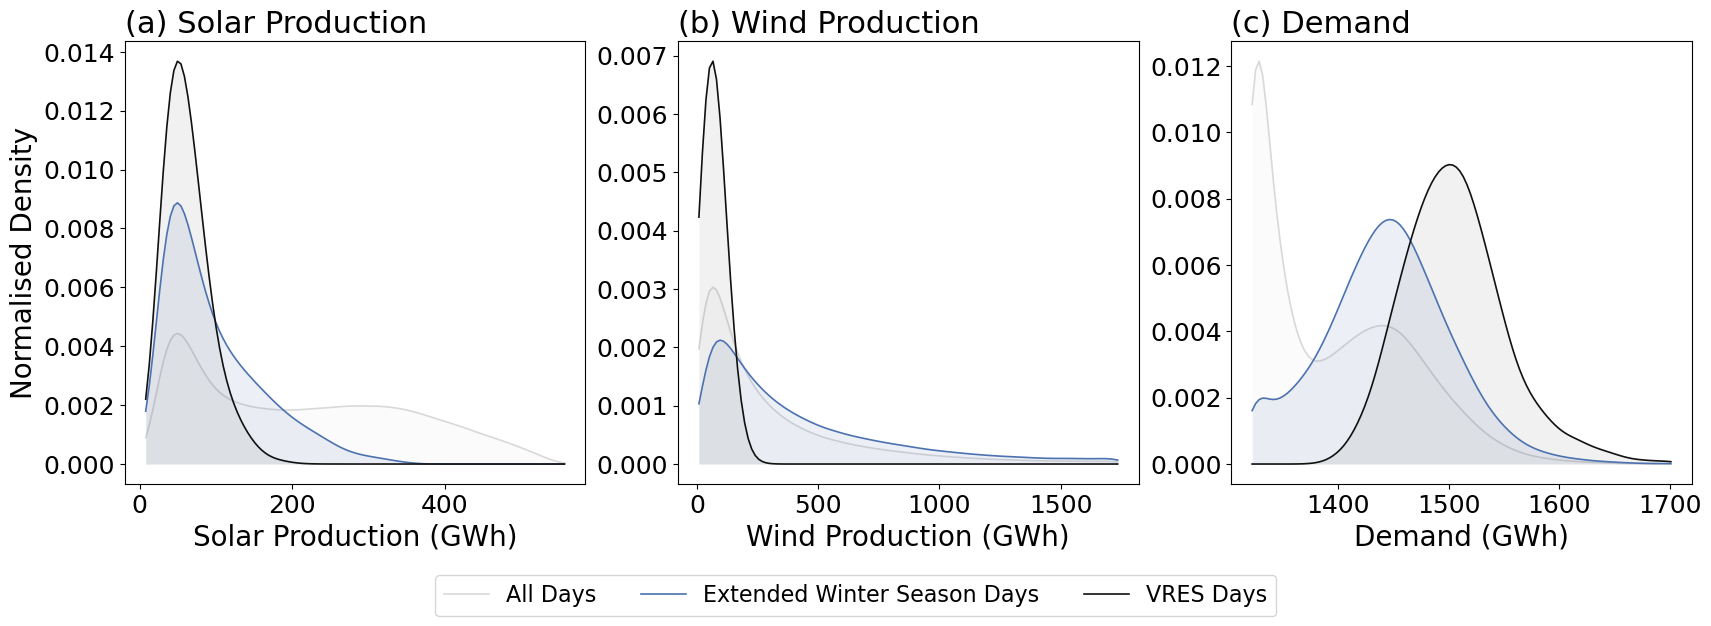

In [11]:
# variables and appearance
columns = [('solar_prod','(a) Solar Production', 'Solar Production (GWh)'), ('wind_total','(b) Wind Production', 'Wind Production (GWh)'), ('demand','(c) Demand', 'Demand (GWh)')]  # cols and pretty names
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (17,5.5)  # figure size
color_all, color_winter, color_filtered = '#d9d9d9','#4c72b0','#111111'  # colors
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------


# make text bigger (global)
mpl.rcParams.update({
    'font.size': 16+4,
    'axes.titlesize': 18+4,
    'axes.labelsize': 16+4,
    'xtick.labelsize': 14+4,
    'ytick.labelsize': 14+4,
    'legend.fontsize': 16+4,
    'figure.titlesize': 18+4,
})


fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=False)  # 3 subplots in a row

for ax, (col, title, xaxis) in zip(axes, columns):
    a = df[col].values  # all data array
    w = df_winter[col].values  # winter array
    f = df_filtered[col].values  # filtered/high-RL array

    # common bin edges spanning min..max across all 3 sets so curves align
    combined_min = min(a.min(), w.min(), f.min())  # global min
    combined_max = max(a.max(), w.max(), f.max())  # global max
    edges = np.linspace(combined_min, combined_max, bins+1)  # bin edges
    centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

    # histogram densities (density=True -> density per unit)
    ca, _ = np.histogram(a, bins=edges, density=True)  # density for all
    cw, _ = np.histogram(w, bins=edges, density=True)  # density for winter
    cf, _ = np.histogram(f, bins=edges, density=True)  # density for filtered

    # smooth densities by convolving with the gaussian kernel
    sa = np.convolve(ca, kernel, mode='same')  # smoothed all
    sw = np.convolve(cw, kernel, mode='same')  # smoothed winter
    sf = np.convolve(cf, kernel, mode='same')  # smoothed filtered

    # normalize each curve to its own peak so every curve's max == 1
    # sa /= max(sa.max(), 1e-12)  # normalize all
    # sw /= max(sw.max(), 1e-12)  # normalize winter
    # sf /= max(sf.max(), 1e-12)  # normalize filtered

    # plotting curves + fills
    ax.plot(centers, sa, lw=lw, color=color_all, label='All', zorder=1)  # all curve
    ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

    ax.plot(centers, sw, lw=lw, color=color_winter, label='Winter', zorder=2)  # winter curve
    ax.fill_between(centers, sw, 0, color=color_winter, alpha=fill_alpha, linewidth=0)  # fill winter

    ax.plot(centers, sf, lw=lw, color=color_filtered, label='VRES', zorder=3)  # filtered curve
    ax.fill_between(centers, sf, 0, color=color_filtered, alpha=0.06, linewidth=0)  # fill filtered

    # labels and styling
    ax.set_title(title, loc='left')  # subplot title
    ax.set_xlabel(xaxis)  # x label
    if ax == axes[0]:
        ax.set_ylabel('Normalised Density')  # y label    ax.grid(True, linestyle=':', alpha=0.4)  # grid
    # ax.legend(fontsize='small')  # legend

# fig.suptitle('Smoothed distributions — All / Winter / VRES (each peak = 1)', y=1.04, fontsize=18)  # overall title

legend_handles = [
    Line2D([0], [0], color=color_all, lw=lw, label='All Days'),
    Line2D([0], [0], color=color_winter, lw=lw, label='Extended Winter Season Days'),
    Line2D([0], [0], color=color_filtered, lw=lw, label='VRES Days'),
]
fig.subplots_adjust(bottom=0.18)  # make room for the legend
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.13), fontsize=16, frameon=True)

# plt.savefig('/home/onennecke/Code/Figures/Contr_RL_Days_dens_curves_0.png', bbox_inches='tight', dpi=300)

plt.show()  # display

### No density curves!

/tmp/ipykernel_3616247/152342486.py:82: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.18)  # make room for the legend


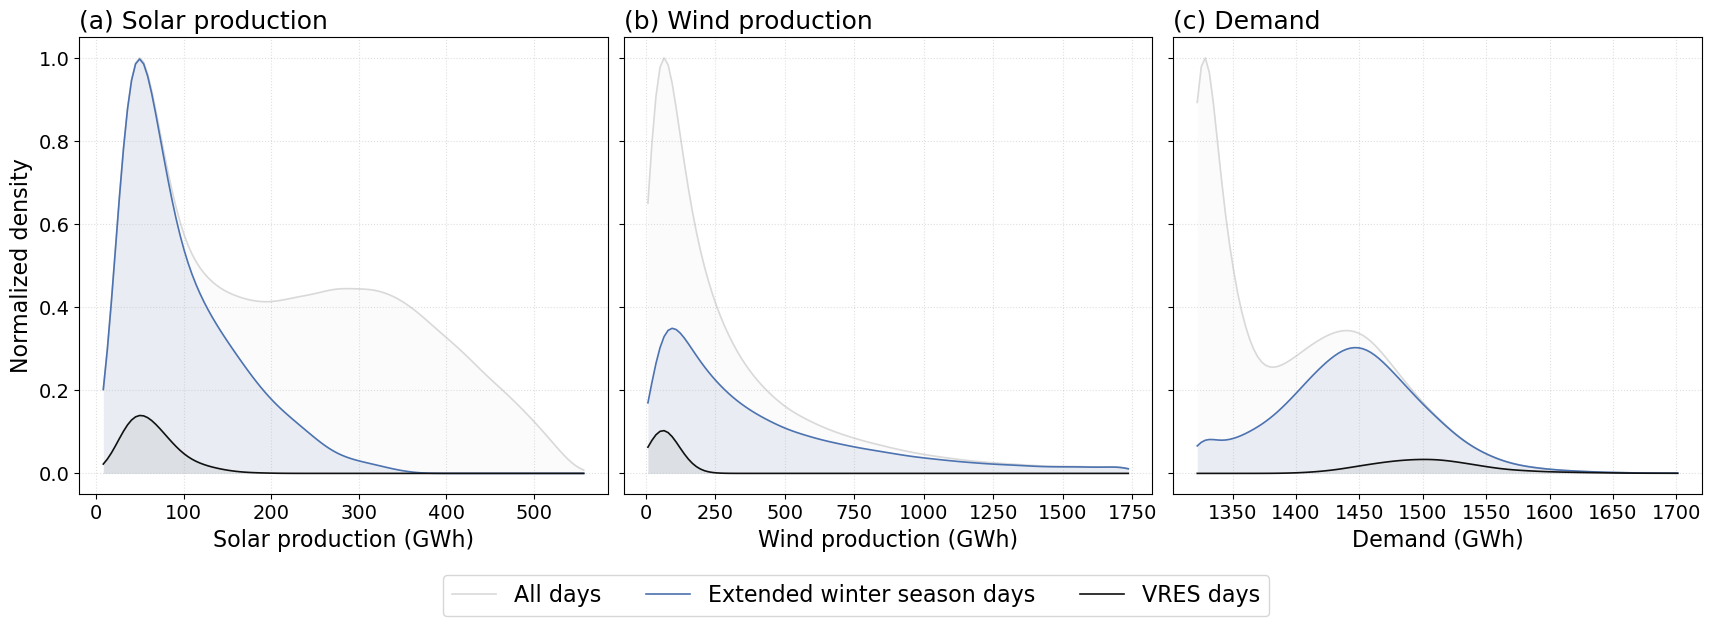

In [12]:
# variables and appearance
columns = [('solar_prod','(a) Solar production', 'Solar production (GWh)'), ('wind_total','(b) Wind production', 'Wind production (GWh)'), ('demand','(c) Demand', 'Demand (GWh)')]  # cols and pretty names
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (17,5.5)  # figure size
color_all, color_winter, color_filtered = '#d9d9d9','#4c72b0','#111111'  # colors
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------


# make text bigger (global)
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# plotting
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=True)  # 3 subplots in a row

for ax, (col, title, xaxis) in zip(axes, columns):
    a = df[col].values  # all data array
    w = df_winter[col].values  # winter array
    f = df_filtered[col].values  # filtered/high-RL array

    # common bin edges spanning min..max across all 3 sets so curves align
    combined_min = min(a.min(), w.min(), f.min())  # global min
    combined_max = max(a.max(), w.max(), f.max())  # global max
    edges = np.linspace(combined_min, combined_max, bins+1)  # bin edges
    centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

    # histogram counts (density=False -> raw counts) computed on the same edges
    ca, _ = np.histogram(a, bins=edges, density=False)  # counts for all
    cw, _ = np.histogram(w, bins=edges, density=False)  # counts for winter
    cf, _ = np.histogram(f, bins=edges, density=False)  # counts for filtered

    # smooth counts by convolving with the gaussian kernel
    sa = np.convolve(ca, kernel, mode='same')  # smoothed all
    sw = np.convolve(cw, kernel, mode='same')  # smoothed winter
    sf = np.convolve(cf, kernel, mode='same')  # smoothed filtered

    # normalize so the largest peak among the three equals 1 (same as your original)
    peak = max(sa.max(), sw.max(), sf.max(), 1e-12)  # avoid division by zero
    sa /= peak  # normalized all
    sw /= peak  # normalized winter
    sf /= peak  # normalized filtered

    # plotting curves + fills
    ax.plot(centers, sa, lw=lw, color=color_all, label='All', zorder=1)  # all curve
    ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

    ax.plot(centers, sw, lw=lw, color=color_winter, label='Winter', zorder=2)  # winter curve
    ax.fill_between(centers, sw, 0, color=color_winter, alpha=fill_alpha, linewidth=0)  # fill winter

    ax.plot(centers, sf, lw=lw, color=color_filtered, label='VRES', zorder=3)  # filtered curve
    ax.fill_between(centers, sf, 0, color=color_filtered, alpha=0.06, linewidth=0)  # fill filtered

    # labels and styling
    ax.set_title(title, loc='left')  # subplot title
    ax.set_xlabel(xaxis)  # x label
    if ax == axes[0]:
        ax.set_ylabel('Normalized density')  # y label
    ax.grid(True, linestyle=':', alpha=0.4)  # grid
    # ax.legend(fontsize='small')  # legend

legend_handles = [
    Line2D([0], [0], color=color_all, lw=lw, label='All days'),
    Line2D([0], [0], color=color_winter, lw=lw, label='Extended winter season days'),
    Line2D([0], [0], color=color_filtered, lw=lw, label='VRES days'),
]
fig.subplots_adjust(bottom=0.18)  # make room for the legend
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.13), fontsize=16, frameon=True)

# slightly larger suptitle
# fig.suptitle('Smoothed distributions', y=1.04, fontsize=18)

# fig.suptitle('Smoothed distributions', y=1.04, fontsize=14)  # overall title

# plt.savefig('/home/onennecke/Code/Figures/Contr_RL_Days_dens_curves_1.png', bbox_inches='tight', dpi=300)

plt.show()  # display


Was bedeutet das:

1. Alle niedrigen Solarwerte sind im Winter
2. Es gibt keine VRES Tage mit hoher Sonnenproduktion, aber die ist auch nicht zwangsläufig ganz niedrig (Kurve wesentlich breiter als bei Wind)
3. Die Verteilung der VRES Tage hat ist ähnlich zu der winter Kurve (etwas verschoben) 
3. Beim Wind ist es anders herum, da sind alle hohen Werte im Winter, es gibt aber auch einige niedrige im Winter
4. Kein VRES Tag hat eine hohe Windproduktion
5. Demand Kurve mit allen Werten hat viele niedrige Werte, und einige in der Mitte
6. Alle Hohen sind im Winter
7. Die VRES Verteilung ist noch höher geshiftet als die des Winters, aber auch hier kommen mittlere Werte vor

/tmp/ipykernel_3616247/1610328488.py:83: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.18)  # make room for the legend


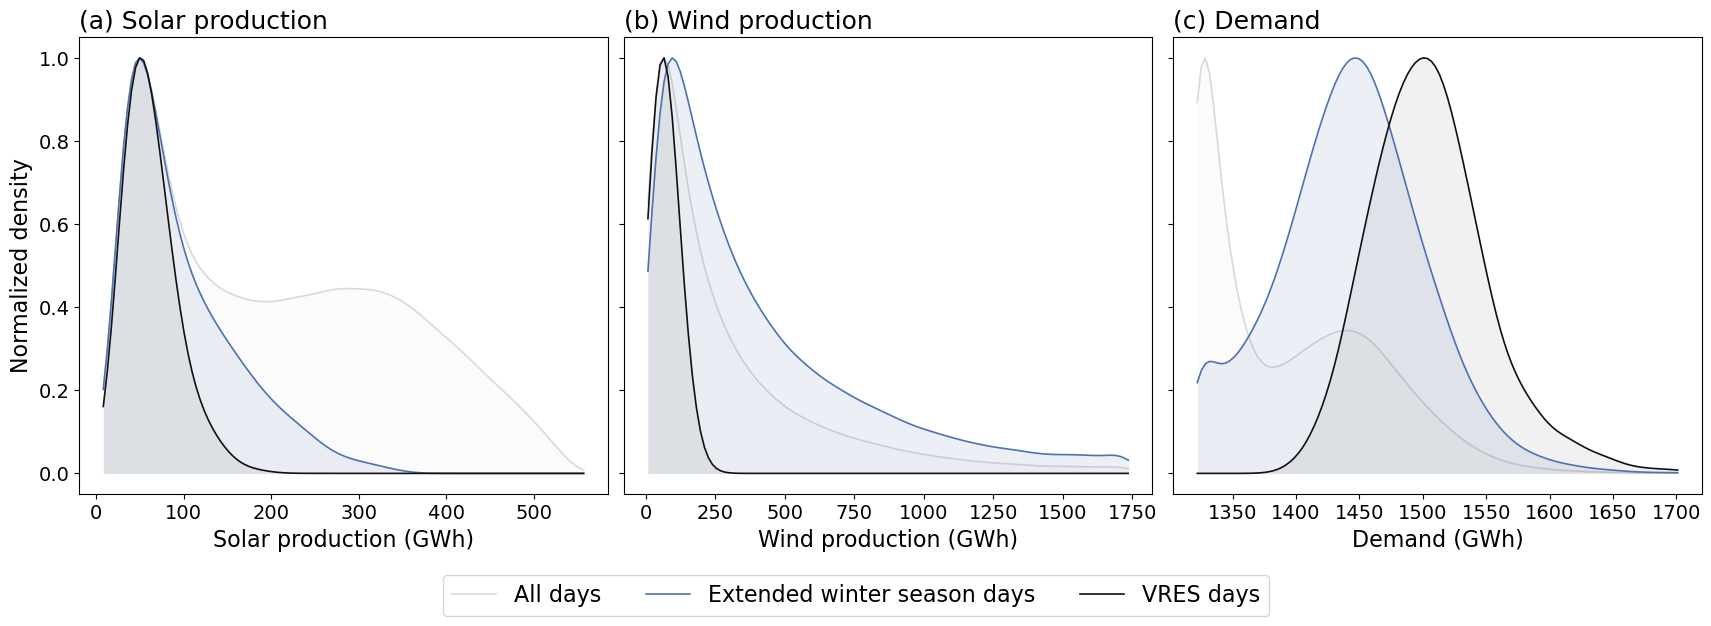

In [13]:
# variables and appearance
columns = [('solar_prod','(a) Solar production', 'Solar production (GWh)'), ('wind_total','(b) Wind production', 'Wind production (GWh)'), ('demand','(c) Demand', 'Demand (GWh)')]  # cols and pretty names
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (17,5.5)  # figure size
color_all, color_winter, color_filtered = '#d9d9d9','#4c72b0','#111111'  # colors
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------


# make text bigger (global)
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})


# plotting
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=True)  # 3 subplots in a row

for ax, (col, title, xaxis) in zip(axes, columns):
    a = df[col].values  # all data array
    w = df_winter[col].values  # winter array
    f = df_filtered[col].values  # filtered/high-RL array

    # common bin edges spanning min..max across all 3 sets so curves align
    combined_min = min(a.min(), w.min(), f.min())  # global min
    combined_max = max(a.max(), w.max(), f.max())  # global max
    edges = np.linspace(combined_min, combined_max, bins+1)  # bin edges
    centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

    # histogram densities (density=True -> density per unit)
    ca, _ = np.histogram(a, bins=edges, density=True)  # density for all
    cw, _ = np.histogram(w, bins=edges, density=True)  # density for winter
    cf, _ = np.histogram(f, bins=edges, density=True)  # density for filtered

    # smooth densities by convolving with the gaussian kernel
    sa = np.convolve(ca, kernel, mode='same')  # smoothed all
    sw = np.convolve(cw, kernel, mode='same')  # smoothed winter
    sf = np.convolve(cf, kernel, mode='same')  # smoothed filtered

    # normalize each curve to its own peak so every curve's max == 1
    sa /= max(sa.max(), 1e-12)  # normalize all
    sw /= max(sw.max(), 1e-12)  # normalize winter
    sf /= max(sf.max(), 1e-12)  # normalize filtered

    # plotting curves + fills
    ax.plot(centers, sa, lw=lw, color=color_all, label='All', zorder=1)  # all curve
    ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

    ax.plot(centers, sw, lw=lw, color=color_winter, label='Winter', zorder=2)  # winter curve
    ax.fill_between(centers, sw, 0, color=color_winter, alpha=fill_alpha, linewidth=0)  # fill winter

    ax.plot(centers, sf, lw=lw, color=color_filtered, label='VRES', zorder=3)  # filtered curve
    ax.fill_between(centers, sf, 0, color=color_filtered, alpha=0.06, linewidth=0)  # fill filtered

    # labels and styling
    ax.set_title(title, loc='left')  # subplot title
    ax.set_xlabel(xaxis)  # x label
    if ax == axes[0]:
        ax.set_ylabel('Normalized density')  # y label    ax.grid(True, linestyle=':', alpha=0.4)  # grid
    # ax.legend(fontsize='small')  # legend

# fig.suptitle('Smoothed distributions — All / Winter / VRES (each peak = 1)', y=1.04, fontsize=18)  # overall title

legend_handles = [
    Line2D([0], [0], color=color_all, lw=lw, label='All days'),
    Line2D([0], [0], color=color_winter, lw=lw, label='Extended winter season days'),
    Line2D([0], [0], color=color_filtered, lw=lw, label='VRES days'),
]
fig.subplots_adjust(bottom=0.18)  # make room for the legend
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.13), fontsize=16, frameon=True)

# plt.savefig('/home/onennecke/Code/Figures/Contr_RL_Days_dens_curves_2.png', bbox_inches='tight', dpi=300)

plt.show()  # display


In [10]:
sa

array([0.90904891, 0.98858732, 1.        , 0.95244044, 0.86677507,
       0.76598125, 0.66759168, 0.58099209, 0.50889853, 0.45030457,
       0.40130562, 0.36401653, 0.33449416, 0.31154633, 0.29415904,
       0.28134827, 0.2721808 , 0.2658964 , 0.26191671, 0.25982675,
       0.25937031, 0.26032472, 0.26248756, 0.26569869, 0.26979506,
       0.2746219 , 0.28001257, 0.28580159, 0.29186415, 0.29811213,
       0.3045786 , 0.31129384, 0.31831727, 0.32561959, 0.3330715 ,
       0.34048069, 0.34763913, 0.35433604, 0.36041265, 0.36572121,
       0.37014868, 0.37359903, 0.37598322, 0.37723636, 0.37731024,
       0.37618041, 0.37382913, 0.37024507, 0.36539914, 0.35927855,
       0.35189683, 0.34329481, 0.33361593, 0.32306413, 0.31187089,
       0.30021248, 0.28821155, 0.27590061, 0.26327484, 0.25035525,
       0.23720908, 0.2239712 , 0.2107825 , 0.19779913, 0.18514653,
       0.17292979, 0.16124504, 0.15016148, 0.13971047, 0.12990361,
       0.12069816, 0.11205653, 0.1039385 , 0.09632957, 0.08922

### Normalization stuff

In [14]:
def normalize_series(arr, method='percentile', robust=False):
    """Return normalized array in [0..1] for percentile/minmax, or zscore for zscore methods."""
    a = np.asarray(arr, dtype=float)
    if method == 'percentile':
        # rank-based percentile (0..1)
        # handle NaN by leaving them as NaN
        sr = pd.Series(a)
        pct = sr.rank(method='average', pct=True)  # 0..1
        return pct.to_numpy()
    elif method == 'minmax':
        mn, mx = np.nanmin(a), np.nanmax(a)
        if mx == mn:
            return np.zeros_like(a)
        return (a - mn) / (mx - mn)
    elif method == 'zscore':
        if robust:
            med = np.nanmedian(a)
            mad = np.nanmedian(np.abs(a - med))
            if mad == 0:
                return np.zeros_like(a)
            return (a - med) / (1.4826 * mad)  # robust z (not bounded)
        else:
            mu = np.nanmean(a)
            sd = np.nanstd(a, ddof=0)
            if sd == 0:
                return np.zeros_like(a)
            return (a - mu) / sd
    else:
        raise ValueError("method must be 'percentile', 'minmax' or 'zscore'")

In [15]:
solar_all = df['solar_prod']
df['solar_norm'] = 1 - normalize_series(solar_all, method='percentile')
wind_all = df['wind_off_prod'] + df['wind_on_prod']
df['wind_norm'] = 1 - normalize_series(wind_all, method='percentile')
demand_all = df['demand']
df['demand_norm'] = normalize_series(demand_all, method='percentile')

# 2) Filter by the threshold
df_filtered = df[df['Residual_load'] > res_load_thresh]

# 3) Drop any remaining rows with NaNs across any column (optional, but you said "without nan values")
df_filtered = df_filtered.dropna(how='any').reset_index(drop=True)

In [16]:
df.columns

Index(['ESM_run', 'time', 'temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax',
       'wind_off_prod', 'wind_on_prod', 'solar_prod', 'total_prod', 'Netto',
       'Residual_load', 'crs', 'gridtype', 'ESM', 'run', 'country', 'period',
       'doy', 'winter', 'wind_total', 'solar_norm', 'wind_norm',
       'demand_norm'],
      dtype='object')

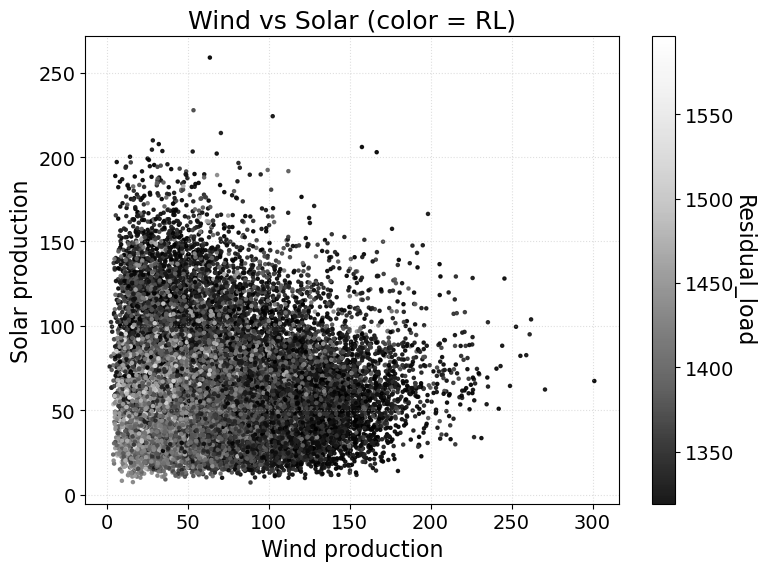

In [17]:

def plot_wind_solar_2d(
    df,
    wind_col='wind',
    solar_col='solar',
    rl_col='rl',
    cmap='Greys_r',   # reversed greys: low -> light, high -> dark
    marker_size=5,
    alpha=0.9,
    figsize=(8,6)
):
    """
    2D scatter: x=wind_col, y=solar_col, color mapped to rl_col (light -> dark).
    """
    x = df[wind_col].to_numpy()
    y = df[solar_col].to_numpy()
    c = df[rl_col].to_numpy()

    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(x, y, c=c, cmap=cmap, s=marker_size, alpha=alpha)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(rl_col, rotation=270, labelpad=15)

    ax.set_xlabel('Wind production')
    ax.set_ylabel('Solar production')
    ax.set_title('Wind vs Solar (color = RL)')
    ax.grid(True, linestyle=':', alpha=0.4)

    plt.tight_layout()
    plt.show()


plot_wind_solar_2d(df_filtered, wind_col='wind_total', solar_col='solar_prod', rl_col='Residual_load')


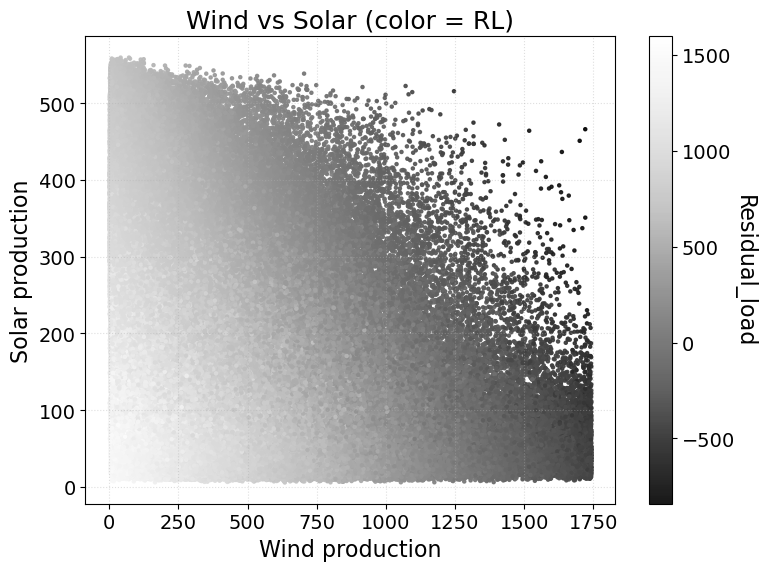

In [18]:
plot_wind_solar_2d(df, wind_col='wind_total', solar_col='solar_prod', rl_col='Residual_load')


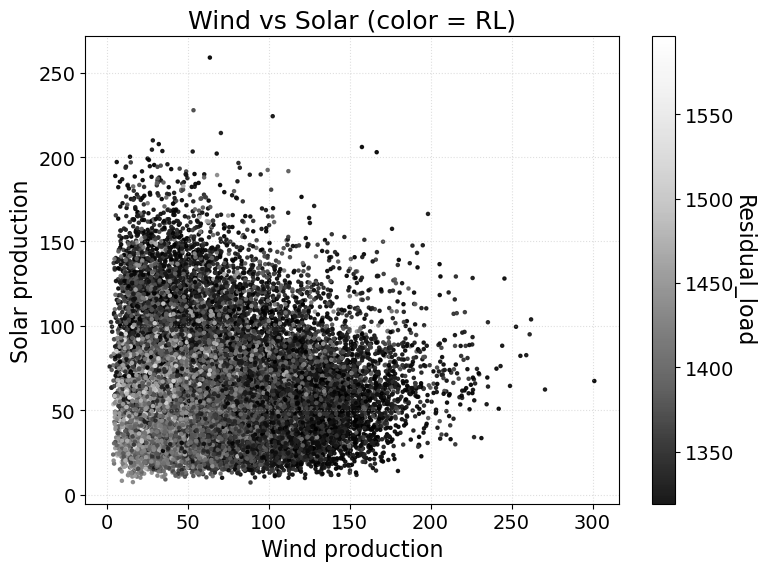

In [19]:

plot_wind_solar_2d(df_filtered, wind_col='wind_total', solar_col='solar_prod', rl_col='Residual_load')


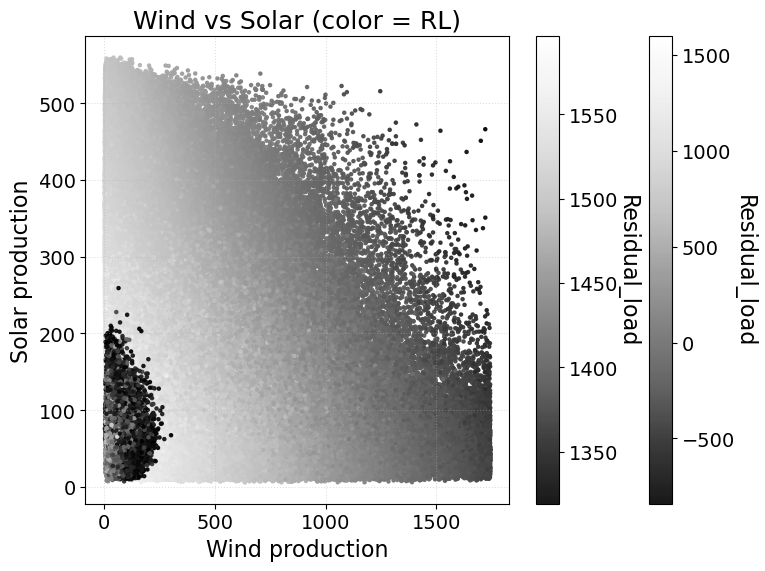

In [20]:
cmap='Greys_r'
marker_size=5
alpha=0.9
figsize=(8,6)
x = df['wind_total'].to_numpy()
y = df['solar_prod'].to_numpy()
c = df['Residual_load'].to_numpy()

fig, ax = plt.subplots(figsize=figsize)
sc = ax.scatter(x, y, c=c, cmap=cmap, s=marker_size, alpha=alpha)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Residual_load', rotation=270, labelpad=15)

ax.set_xlabel('Wind production')
ax.set_ylabel('Solar production')
ax.set_title('Wind vs Solar (color = RL)')
ax.grid(True, linestyle=':', alpha=0.4)

# plt.tight_layout()
# plt.show()



# --- Extract arrays (use the same DataFrame/column names that exist) ---
x = df_filtered['wind_total'].to_numpy()
y = df_filtered['solar_prod'].to_numpy()
c = df_filtered['Residual_load'].to_numpy()

# --- Plot ---
sc = ax.scatter(x, y, c=c, cmap=cmap, s=marker_size, alpha=alpha)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Residual_load', rotation=270, labelpad=15)

ax.set_xlabel('Wind production')
ax.set_ylabel('Solar production')
ax.set_title('Wind vs Solar (color = RL)')
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

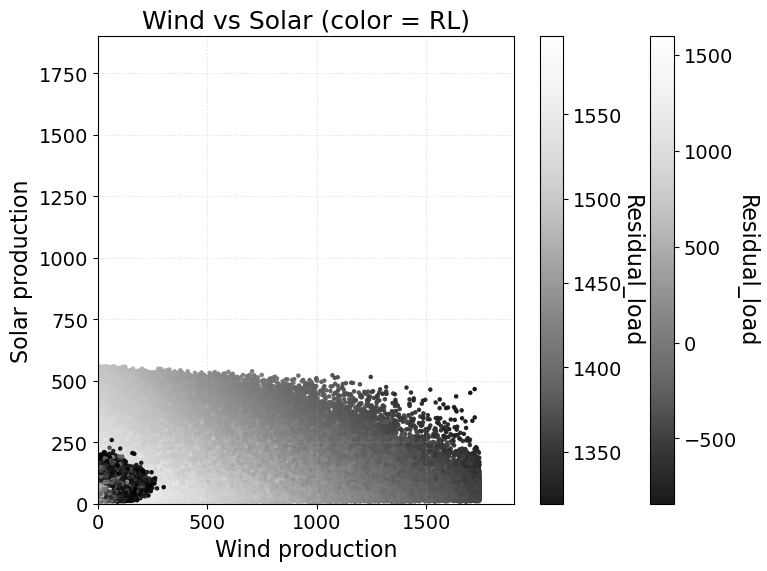

In [21]:
cmap='Greys_r'
marker_size=5
alpha=0.9
figsize=(8,6)
x = df['wind_total'].to_numpy()
y = df['solar_prod'].to_numpy()
c = df['Residual_load'].to_numpy()

fig, ax = plt.subplots(figsize=figsize)
sc = ax.scatter(x, y, c=c, cmap=cmap, s=marker_size, alpha=alpha)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Residual_load', rotation=270, labelpad=15)

ax.set_xlabel('Wind production')
ax.set_ylabel('Solar production')
ax.set_title('Wind vs Solar (color = RL)')
ax.grid(True, linestyle=':', alpha=0.4)

# plt.tight_layout()
# plt.show()



# --- Extract arrays (use the same DataFrame/column names that exist) ---
x = df_filtered['wind_total'].to_numpy()
y = df_filtered['solar_prod'].to_numpy()
c = df_filtered['Residual_load'].to_numpy()

# --- Plot ---
sc = ax.scatter(x, y, c=c, cmap=cmap, s=marker_size, alpha=alpha)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Residual_load', rotation=270, labelpad=15)

ax.set_xlim(0, 1900)
ax.set_ylim(0, 1900)

ax.set_xlabel('Wind production')
ax.set_ylabel('Solar production')
ax.set_title('Wind vs Solar (color = RL)')
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

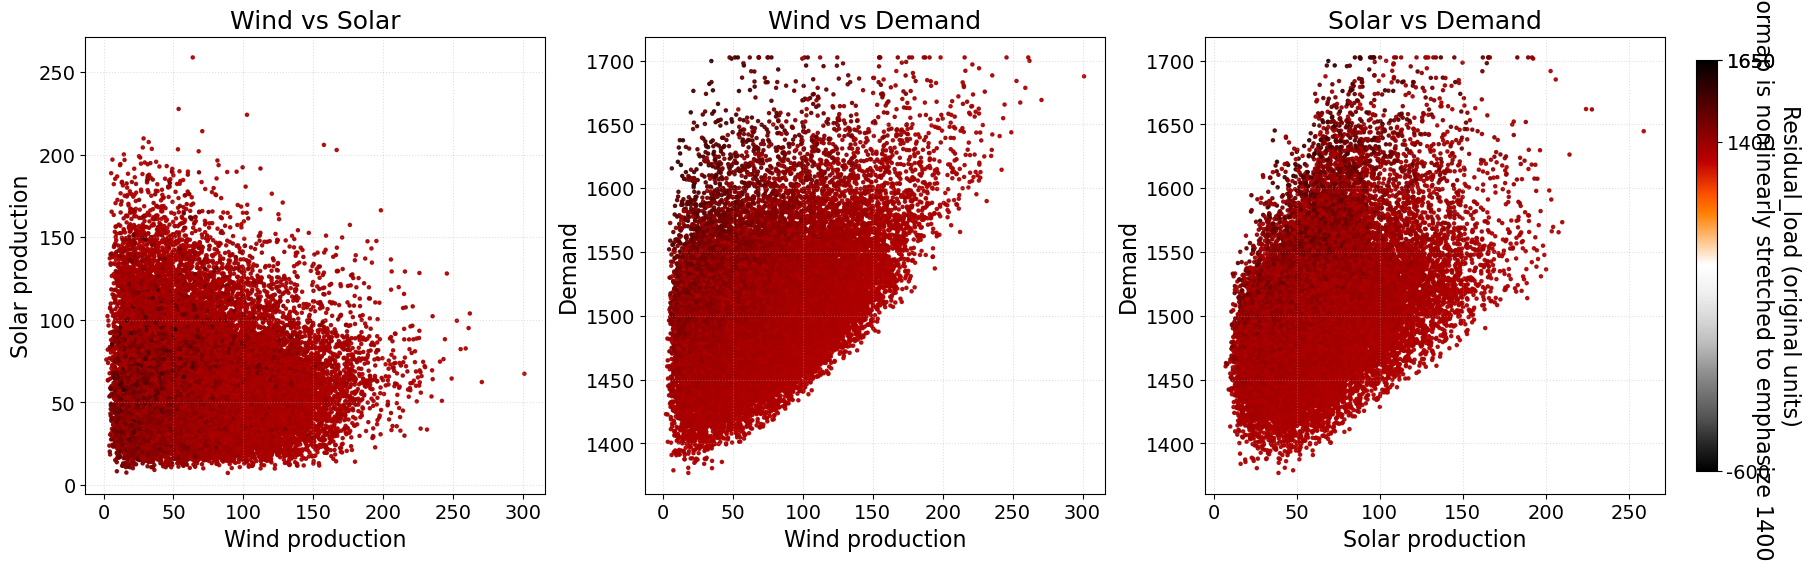

In [22]:


# --- user-tweakable parameters ------------------------------------------------
marker_size = 5
alpha = 0.9
figsize = (18, 5.5)           # 3 plots side-by-side
cmap_lower = plt.cm.Greys_r  # colormap for lower/bulk range
cmap_upper = plt.cm.gist_heat_r  # colormap for emphasized upper range

# RL stretch parameters (change if you want a different emphasized subrange)
low = -600      # left-most value shown (mapped -> 0)
mid1 = 1400     # end of bulk range (mapped -> 0.8)
mid2 = 1650     # end of emphasized range (mapped -> 1.0)
# ------------------------------------------------------------------------------

# build combined colormap (128 from each -> 256 colors)
colors1 = cmap_lower(np.linspace(0.0, 1.0, 128))
colors2 = cmap_upper(np.linspace(0.0, 1.0, 128))
colors = np.vstack((colors1, colors2))
combined_cmap = mcolors.LinearSegmentedColormap.from_list("combined_rl", colors)

# scaling function: map original RL values -> [0,1] nonlinearly
def scale_rl(c, low=low, mid1=mid1, mid2=mid2):
    c = np.asarray(c, dtype=float)
    scaled = np.zeros_like(c, dtype=float)

    # region 1: <= low -> 0
    mask = c <= low
    scaled[mask] = 0.0

    # region 2: low < c <= mid1 -> linear to [0, 0.8]
    mask = (c > low) & (c <= mid1)
    scaled[mask] = ((c[mask] - low) / (mid1 - low)) * 0.8

    # region 3: mid1 < c <= mid2 -> linear to [0.8, 1.0]
    mask = (c > mid1) & (c <= mid2)
    scaled[mask] = 0.8 + ((c[mask] - mid1) / (mid2 - mid1)) * 0.2

    # region 4: > mid2 -> 1.0
    mask = c > mid2
    scaled[mask] = 1.0

    # NaNs remain NaN
    scaled[np.isnan(c)] = np.nan
    return scaled

# prepare data arrays (drop NaNs for plotting but keep mapping consistent)
x1 = df_filtered['wind_total'].to_numpy()
y1 = df_filtered['solar_prod'].to_numpy()
x2 = df_filtered['wind_total'].to_numpy()
y2 = df_filtered['demand'].to_numpy()
x3 = df_filtered['solar_prod'].to_numpy()
y3 = df_filtered['demand'].to_numpy()
c_orig = df_filtered['Residual_load'].to_numpy()

# compute scaled color values
c_scaled = scale_rl(c_orig)

# create figure and axes
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=False)

pairs = [
    (x1, y1, 'Wind production', 'Solar production', 'Wind vs Solar'),
    (x2, y2, 'Wind production', 'Demand', 'Wind vs Demand'),
    (x3, y3, 'Solar production', 'Demand', 'Solar vs Demand'),
]

# plot each subplot using the SAME scaled c values and same colormap (vmin=0, vmax=1)
for ax, (xx, yy, xlabel, ylabel, title) in zip(axes, pairs):
    # mask rows where x or y or color is nan
    mask = np.isfinite(xx) & np.isfinite(yy) & np.isfinite(c_scaled)
    sc = ax.scatter(xx[mask], yy[mask], c=c_scaled[mask], cmap=combined_cmap,
                    s=marker_size, alpha=alpha, vmin=0.0, vmax=1.0)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.4)

# build a single colorbar for all three plots (show ticks in original RL units)
# Create a ScalarMappable to feed the colorbar (norm 0..1 because we pre-scaled to 0..1)
mappable = plt.cm.ScalarMappable(cmap=combined_cmap, norm=plt.Normalize(vmin=0.0, vmax=1.0))
mappable.set_array([])  # required for colorbar

# choose tick positions in original RL units and convert to normalized positions
data_max = np.nanmax(c_orig)
tick_vals = [low, mid1, mid2, max(mid2, data_max)]
tick_norms = scale_rl(np.array(tick_vals))
cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_ticks(tick_norms)
cbar.set_ticklabels([f'{v:g}' for v in tick_vals])
cbar.set_label('Residual_load (original units)\n(note: colormap is nonlinearly stretched to emphasize 1400–1650)', rotation=270, labelpad=18)

plt.show()


In [23]:
# Pick ERA5_week ESM and 06.11.2024
df_filtered_CS = df_filtered[(df_filtered['ESM'] == 'ERA5_week') & (df_filtered['time'] == '2024-11-06')]
df_filtered_CS

,ESM_run,time,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,...,ESM,run,country,period,doy,winter,wind_total,solar_norm,wind_norm,demand_norm


In [24]:
df = df.loc[df['solar_prod'] != 0].dropna(how='any').reset_index(drop=True)
df_filtered = df_filtered.loc[df_filtered['solar_prod'] != 0].dropna(how='any').reset_index(drop=True)

In [25]:
704450 - 704347 

103

In [26]:
# Show 10 smallest solar_prod values
df.nsmallest(10, 'solar_prod')[['ESM', 'time', 'solar_prod', 'wind_total', 'demand', 'Residual_load']]

,ESM,time,solar_prod,wind_total,demand,Residual_load
100366,CESM2,2043-12-23,5.809632,634.851079,1423.377299,782.716588
12051,BCC-CSM2-MR,2042-01-07,5.971619,165.632322,1452.882401,1281.278459
13875,BCC-CSM2-MR,2047-01-06,5.985558,799.990017,1460.096409,654.120834
336527,CESM2,2040-12-29,6.068309,1175.453209,1388.197040,206.675523
11292,BCC-CSM2-MR,2039-12-09,6.077913,1054.358305,1413.258042,352.821824
12026,BCC-CSM2-MR,2041-12-13,6.249564,1389.873476,1399.519325,3.396285
11284,BCC-CSM2-MR,2039-12-01,6.588866,427.624916,1465.720143,1031.506360
11324,BCC-CSM2-MR,2040-01-10,6.604773,344.787830,1443.124001,1091.731398
77013,CESM2,2039-12-30,6.710141,843.813002,1397.523858,547.000715
625595,MPI-ESM1-2-HR,2042-12-17,6.757150,831.210889,1447.015844,609.047804


/tmp/ipykernel_3616247/2988249410.py:161: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  ax.scatter(


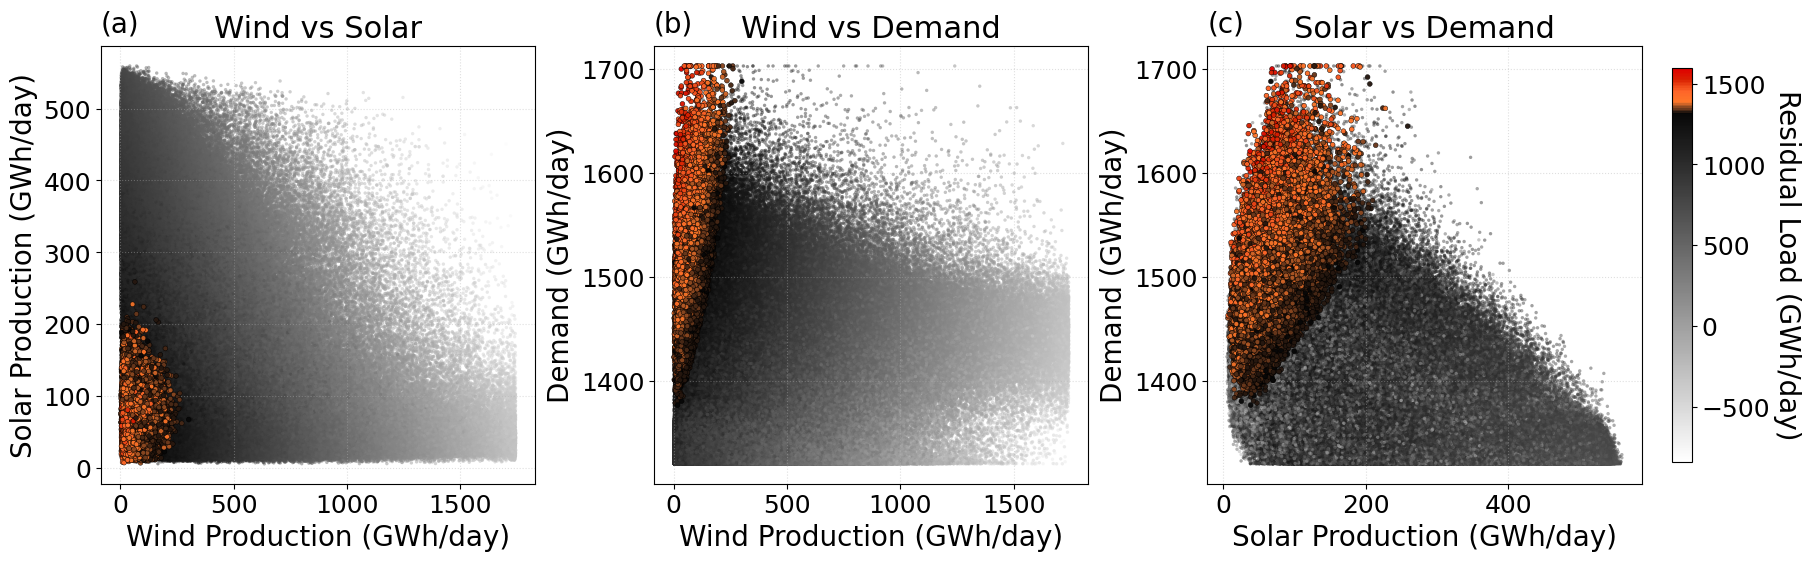

In [27]:


mpl.rcParams.update({
    'font.size': 16+4,
    'axes.titlesize': 18+4,
    'axes.labelsize': 16+4,
    'xtick.labelsize': 14+4,
    'ytick.labelsize': 14+4,
    'legend.fontsize': 16+4,
    'figure.titlesize': 18+4,
})


# -------------- user parameters --------------
marker_all = 6
marker_filt = 12
alpha_all = 0.45
alpha_filt = 0.95
figsize = (18, 5.5)

# base colormaps you want to combine
cmap_low = plt.cm.binary        # used for the lower/majority range
# cmap_high = plt.cm.gist_heat_r  # used only for the top portion
# orig = plt.cm.gist_heat_r
# colors = orig(np.linspace(0.0, 1.0, 256))
# # replace the darkest color with a dark red (hex chosen here)
# colors[-1] = mcolors.to_rgba("#bb0000")
# cmap_high = mcolors.LinearSegmentedColormap.from_list('gist_heat_r_darkred_end', colors)

# cmap_high = plt.cm.get_cmap('YlOrRd')  # less custom but also avoids black
cmap_high = mcolors.LinearSegmentedColormap.from_list(
    'yellow_orange_darkred',
    ["#fe8f4f", "#fe7729", "#fe6529", "#d92101", "#df0000"]  # light yellow -> orange -> dark red
)


# fraction of the colormap to reserve for cmap_high (top of the scale)
upper_frac = 0.05   # 0.05 -> top 5% of colors come from cmap_high

# number of discrete colors in combined map (higher -> smoother)
ncolors = 256

# seam blending width in colors (to smooth transition); small integer like 6..12
blend = 8
# ----------------------------------------------

# ------------------ Replace previous colormap-building with this ------------------
# threshold in original Residual_load units (set to the value you want)
threshold = 1319.1588066525014
# 1398.1161147066591  # <- change this to your desired threshold

# ensure vmin/vmax are available (if not, derive from combined df + df_filtered)
if 'vmin' not in globals() or 'vmax' not in globals():
    c_pool = np.concatenate([
        df['Residual_load'].to_numpy().ravel(),
        df_filtered['Residual_load'].to_numpy().ravel()
    ])
    c_pool = c_pool[np.isfinite(c_pool)]
    if c_pool.size == 0:
        raise RuntimeError("No finite Residual_load values found in df / df_filtered.")
    vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# compute upper_frac from threshold relative to the vmin..vmax range
# if threshold >= vmax -> upper_frac = 0 (no high-colormap)
# if threshold <= vmin -> upper_frac = 1 (all high-colormap)
if vmax <= vmin:
    upper_frac = 0.5  # fallback if degenerate range
else:
    upper_frac = (vmax - threshold) / (vmax - vmin)
    upper_frac = float(np.clip(upper_frac, 0.0, 1.0))

# --- optional alternative: compute fraction based on empirical proportion of points above threshold
# uncomment to use empirical fraction (may be preferable if distribution is skewed)
# c_pool_vals = c_pool  # from above
# upper_frac = np.mean(c_pool_vals >= threshold)

# convert fraction to discrete color counts
n_high = max(2, int(round(upper_frac * ncolors)))
n_low = max(2, ncolors - n_high)
# ensure exact total
if n_low + n_high != ncolors:
    n_low = ncolors - n_high

# sample the two colormaps
colors_low = cmap_low(np.linspace(0.0, 1.0, n_low))
colors_high = cmap_high(np.linspace(0.0, 1.0, n_high))

# create a blended seam to avoid a hard cut (uses `blend` from your config)
if blend > 0:
    b = min(blend, n_low - 1, n_high - 1)
    if b > 0:
        seam_low = colors_low[-b:]
        seam_high = colors_high[:b]
        blended = np.array([ (1 - t) * sl + t * sh for t, sl, sh in zip(np.linspace(0,1,b), seam_low, seam_high) ])
        colors = np.vstack([colors_low[:-b], blended, colors_high[b:]])
    else:
        colors = np.vstack([colors_low, colors_high])
else:
    colors = np.vstack([colors_low, colors_high])

# final combined colormap
combined_cmap = mcolors.LinearSegmentedColormap.from_list("combined_top_threshold", colors)
# -----------------------------------------------------------------------------------


# plotting pairs
pairs = [
    ('wind_total', 'solar_prod', 'Wind Production (GWh/day)', 'Solar Production (GWh/day)', 'Wind vs Solar'),
    ('wind_total', 'demand', 'Wind Production (GWh/day)', 'Demand (GWh/day)', 'Wind vs Demand'),
    ('solar_prod', 'demand', 'Solar Production (GWh/day)', 'Demand (GWh/day)', 'Solar vs Demand'),
]

# determine shared vmin/vmax from both dataframes (no scaling)
c_pool = np.concatenate([
    df['Residual_load'].to_numpy().ravel(),
    df_filtered['Residual_load'].to_numpy().ravel()
])
c_pool = c_pool[np.isfinite(c_pool)]
if c_pool.size == 0:
    raise RuntimeError("No finite Residual_load values in df / df_filtered.")
vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# create figure and axes
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=False)

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, pairs):
    # background: df
    x_all = df[xcol].to_numpy()
    y_all = df[ycol].to_numpy()
    c_all = df['Residual_load'].to_numpy()
    mask_all = np.isfinite(x_all) & np.isfinite(y_all) & np.isfinite(c_all)
    sc_all = ax.scatter(
        x_all[mask_all], y_all[mask_all],
        c=c_all[mask_all],
        cmap=combined_cmap,
        s=marker_all,
        alpha=alpha_all,
        vmin=vmin, vmax=vmax,
        edgecolors='none', zorder=1
    )
    
    # foreground: df_filtered
    x_f = df_filtered[xcol].to_numpy()
    y_f = df_filtered[ycol].to_numpy()
    c_f = df_filtered['Residual_load'].to_numpy()
    mask_f = np.isfinite(x_f) & np.isfinite(y_f) & np.isfinite(c_f)
    sc_f = ax.scatter(
        x_f[mask_f], y_f[mask_f],
        c=c_f[mask_f],
        cmap=combined_cmap,
        s=marker_filt,
        alpha=alpha_filt,
        vmin=vmin, vmax=vmax,
        edgecolors='black', linewidths=0.35, zorder=3
    )
    # ax.set_xlim(min(df['solar_prod'].min(), df['wind_total'].min(), df['demand'].min()), max(df['solar_prod'].max(), df['wind_total'].max(), df['demand'].max()))
    # ax.set_ylim(min(df['solar_prod'].min(), df['wind_total'].min(), df['demand'].min()), max(df['solar_prod'].max(), df['wind_total'].max(), df['demand'].max()))

    # Set star marker at df_filtered_CS
    x_cs = df_filtered_CS[xcol].to_numpy()
    y_cs = df_filtered_CS[ycol].to_numpy()
    # c_cs = df_filtered_CS['Residual_load'].to_numpy()
    ax.scatter(
        x_cs, y_cs,
        c="#E69F00",
        cmap=combined_cmap,
        s=marker_filt * 30,
        alpha=1.0,
        vmin=vmin, vmax=vmax,
        edgecolors='black', linewidths=1.0,
        marker='*',
        zorder=4
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.4)

    # # simple legend for roles (not color)
    # legend_elements = [
    #     Line2D([0], [0], marker='o', color='w', label='All days',
    #            markerfacecolor='gray', markersize=7, alpha=alpha_all),
    #     Line2D([0], [0], marker='o', color='w', label='Filtered / VRES',
    #            markerfacecolor='gray', markeredgecolor='k', markersize=10, alpha=alpha_filt)
    # ]
    # ax.legend(handles=legend_elements, loc='upper right')

# left-aligned, not bold, placed just above each subplot
for i, ax in enumerate(axes):
    label = f'({chr(ord("a") + i)})'
    # y slightly above the axis (1.02); use va='bottom' so text sits above the top edge
    ax.text(0.0, 1.02, label,
            transform=ax.transAxes,
            fontweight='normal',  # not bold
            ha='left',
            va='bottom')

# single shared colorbar (maps numeric RL values to the combined colormap)
mappable = plt.cm.ScalarMappable(cmap=combined_cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label('Residual Load (GWh/day)', rotation=270, labelpad=22)

# Save plot
# plt.savefig('/home/onennecke/Code/Figures/Sctrplt_composition_marker.png', bbox_inches='tight', dpi=300)
# plt.savefig('/home/onennecke/Code/Figures/Sctrplt_composition_poster.png', bbox_inches='tight', dpi=300)

plt.show()


/tmp/ipykernel_3616247/2713050098.py:177: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  ax.scatter(


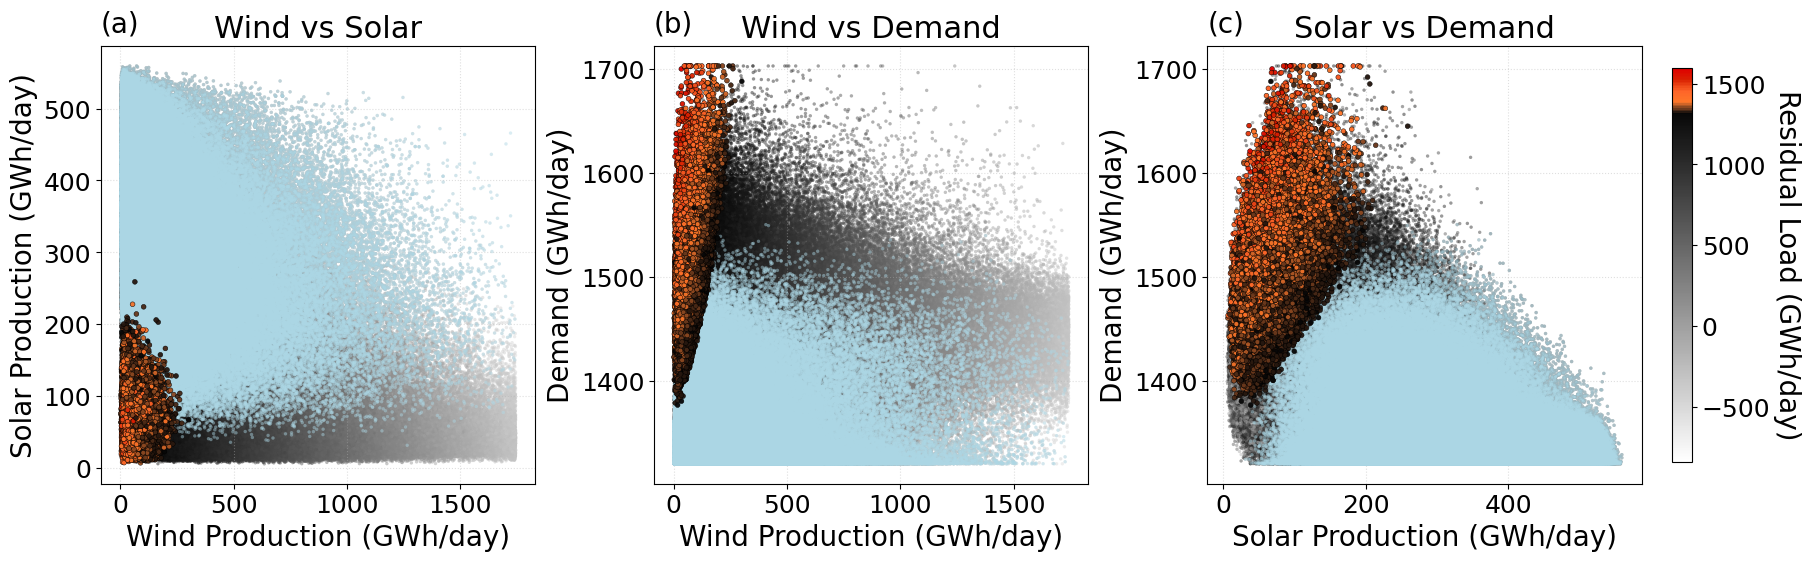

In [28]:


mpl.rcParams.update({
    'font.size': 16+4,
    'axes.titlesize': 18+4,
    'axes.labelsize': 16+4,
    'xtick.labelsize': 14+4,
    'ytick.labelsize': 14+4,
    'legend.fontsize': 16+4,
    'figure.titlesize': 18+4,
})


# -------------- user parameters --------------
marker_all = 6
marker_filt = 12
alpha_all = 0.45
alpha_filt = 0.95
figsize = (18, 5.5)

# base colormaps you want to combine
cmap_low = plt.cm.binary        # used for the lower/majority range
# cmap_high = plt.cm.gist_heat_r  # used only for the top portion
# orig = plt.cm.gist_heat_r
# colors = orig(np.linspace(0.0, 1.0, 256))
# # replace the darkest color with a dark red (hex chosen here)
# colors[-1] = mcolors.to_rgba("#bb0000")
# cmap_high = mcolors.LinearSegmentedColormap.from_list('gist_heat_r_darkred_end', colors)

# cmap_high = plt.cm.get_cmap('YlOrRd')  # less custom but also avoids black
cmap_high = mcolors.LinearSegmentedColormap.from_list(
    'yellow_orange_darkred',
    ["#fe8f4f", "#fe7729", "#fe6529", "#d92101", "#df0000"]  # light yellow -> orange -> dark red
)


# fraction of the colormap to reserve for cmap_high (top of the scale)
upper_frac = 0.05   # 0.05 -> top 5% of colors come from cmap_high

# number of discrete colors in combined map (higher -> smoother)
ncolors = 256

# seam blending width in colors (to smooth transition); small integer like 6..12
blend = 8
# ----------------------------------------------

# ------------------ Replace previous colormap-building with this ------------------
# threshold in original Residual_load units (set to the value you want)
threshold = 1319.1588066525014
# 1398.1161147066591  # <- change this to your desired threshold

# ensure vmin/vmax are available (if not, derive from combined df + df_filtered)
if 'vmin' not in globals() or 'vmax' not in globals():
    c_pool = np.concatenate([
        df['Residual_load'].to_numpy().ravel(),
        df_filtered['Residual_load'].to_numpy().ravel()
    ])
    c_pool = c_pool[np.isfinite(c_pool)]
    if c_pool.size == 0:
        raise RuntimeError("No finite Residual_load values found in df / df_filtered.")
    vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# compute upper_frac from threshold relative to the vmin..vmax range
# if threshold >= vmax -> upper_frac = 0 (no high-colormap)
# if threshold <= vmin -> upper_frac = 1 (all high-colormap)
if vmax <= vmin:
    upper_frac = 0.5  # fallback if degenerate range
else:
    upper_frac = (vmax - threshold) / (vmax - vmin)
    upper_frac = float(np.clip(upper_frac, 0.0, 1.0))

# --- optional alternative: compute fraction based on empirical proportion of points above threshold
# uncomment to use empirical fraction (may be preferable if distribution is skewed)
# c_pool_vals = c_pool  # from above
# upper_frac = np.mean(c_pool_vals >= threshold)

# convert fraction to discrete color counts
n_high = max(2, int(round(upper_frac * ncolors)))
n_low = max(2, ncolors - n_high)
# ensure exact total
if n_low + n_high != ncolors:
    n_low = ncolors - n_high

# sample the two colormaps
colors_low = cmap_low(np.linspace(0.0, 1.0, n_low))
colors_high = cmap_high(np.linspace(0.0, 1.0, n_high))

# create a blended seam to avoid a hard cut (uses `blend` from your config)
if blend > 0:
    b = min(blend, n_low - 1, n_high - 1)
    if b > 0:
        seam_low = colors_low[-b:]
        seam_high = colors_high[:b]
        blended = np.array([ (1 - t) * sl + t * sh for t, sl, sh in zip(np.linspace(0,1,b), seam_low, seam_high) ])
        colors = np.vstack([colors_low[:-b], blended, colors_high[b:]])
    else:
        colors = np.vstack([colors_low, colors_high])
else:
    colors = np.vstack([colors_low, colors_high])

# final combined colormap
combined_cmap = mcolors.LinearSegmentedColormap.from_list("combined_top_threshold", colors)
# -----------------------------------------------------------------------------------


# plotting pairs
pairs = [
    ('wind_total', 'solar_prod', 'Wind Production (GWh/day)', 'Solar Production (GWh/day)', 'Wind vs Solar'),
    ('wind_total', 'demand', 'Wind Production (GWh/day)', 'Demand (GWh/day)', 'Wind vs Demand'),
    ('solar_prod', 'demand', 'Solar Production (GWh/day)', 'Demand (GWh/day)', 'Solar vs Demand'),
]

# determine shared vmin/vmax from both dataframes (no scaling)
c_pool = np.concatenate([
    df['Residual_load'].to_numpy().ravel(),
    df_winter['Residual_load'].to_numpy().ravel(),
    df_filtered['Residual_load'].to_numpy().ravel()
])
c_pool = c_pool[np.isfinite(c_pool)]
if c_pool.size == 0:
    raise RuntimeError("No finite Residual_load values in df / df_filtered.")
vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# create figure and axes
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=False)

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, pairs):
    # background: df
    x_all = df[xcol].to_numpy()
    y_all = df[ycol].to_numpy()
    c_all = df['Residual_load'].to_numpy()
    mask_all = np.isfinite(x_all) & np.isfinite(y_all) & np.isfinite(c_all)
    sc_all = ax.scatter(
        x_all[mask_all], y_all[mask_all],
        c=c_all[mask_all],
        cmap=combined_cmap,
        s=marker_all,
        alpha=alpha_all,
        vmin=vmin, vmax=vmax,
        edgecolors='none', zorder=1
    )
    
    # background: df_winter
    x_w = df_summer[xcol].to_numpy()
    y_w = df_summer[ycol].to_numpy()
    c_w = df_summer['Residual_load'].to_numpy()
    mask_w = np.isfinite(x_w) & np.isfinite(y_w) & np.isfinite(c_w)
    sc_w = ax.scatter(
        x_w[mask_w], y_w[mask_w],
        c=c_w[mask_w],
        cmap=mcolors.LinearSegmentedColormap.from_list('light_blue', ["#add8e6", "#add8e6"]),
        s=marker_all,
        alpha=alpha_all,
        vmin=vmin, vmax=vmax,
        edgecolors='none', zorder=2
    )
    
    # foreground: df_filtered
    x_f = df_filtered[xcol].to_numpy()
    y_f = df_filtered[ycol].to_numpy()
    c_f = df_filtered['Residual_load'].to_numpy()
    mask_f = np.isfinite(x_f) & np.isfinite(y_f) & np.isfinite(c_f)
    sc_f = ax.scatter(
        x_f[mask_f], y_f[mask_f],
        c=c_f[mask_f],
        cmap=combined_cmap,
        s=marker_filt,
        alpha=alpha_filt,
        vmin=vmin, vmax=vmax,
        edgecolors='black', linewidths=0.35, zorder=3
    )
    # ax.set_xlim(min(df['solar_prod'].min(), df['wind_total'].min(), df['demand'].min()), max(df['solar_prod'].max(), df['wind_total'].max(), df['demand'].max()))
    # ax.set_ylim(min(df['solar_prod'].min(), df['wind_total'].min(), df['demand'].min()), max(df['solar_prod'].max(), df['wind_total'].max(), df['demand'].max()))

    # Set star marker at df_filtered_CS
    x_cs = df_filtered_CS[xcol].to_numpy()
    y_cs = df_filtered_CS[ycol].to_numpy()
    # c_cs = df_filtered_CS['Residual_load'].to_numpy()
    ax.scatter(
        x_cs, y_cs,
        c="#E69F00",
        cmap=combined_cmap,
        s=marker_filt * 30,
        alpha=1.0,
        vmin=vmin, vmax=vmax,
        edgecolors='black', linewidths=1.0,
        marker='*',
        zorder=4
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.4)

    # # simple legend for roles (not color)
    # legend_elements = [
    #     Line2D([0], [0], marker='o', color='w', label='All days',
    #            markerfacecolor='gray', markersize=7, alpha=alpha_all),
    #     Line2D([0], [0], marker='o', color='w', label='Filtered / VRES',
    #            markerfacecolor='gray', markeredgecolor='k', markersize=10, alpha=alpha_filt)
    # ]
    # ax.legend(handles=legend_elements, loc='upper right')

# left-aligned, not bold, placed just above each subplot
for i, ax in enumerate(axes):
    label = f'({chr(ord("a") + i)})'
    # y slightly above the axis (1.02); use va='bottom' so text sits above the top edge
    ax.text(0.0, 1.02, label,
            transform=ax.transAxes,
            fontweight='normal',  # not bold
            ha='left',
            va='bottom')

# single shared colorbar (maps numeric RL values to the combined colormap)
mappable = plt.cm.ScalarMappable(cmap=combined_cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label('Residual Load (GWh/day)', rotation=270, labelpad=22)

# Save plot
# plt.savefig('/home/onennecke/Code/Figures/Sctrplt_composition_marker.png', bbox_inches='tight', dpi=300)
# plt.savefig('/home/onennecke/Code/Figures/Sctrplt_composition_poster.png', bbox_inches='tight', dpi=300)

plt.show()


/tmp/ipykernel_593677/2713050098.py:177: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  ax.scatter(


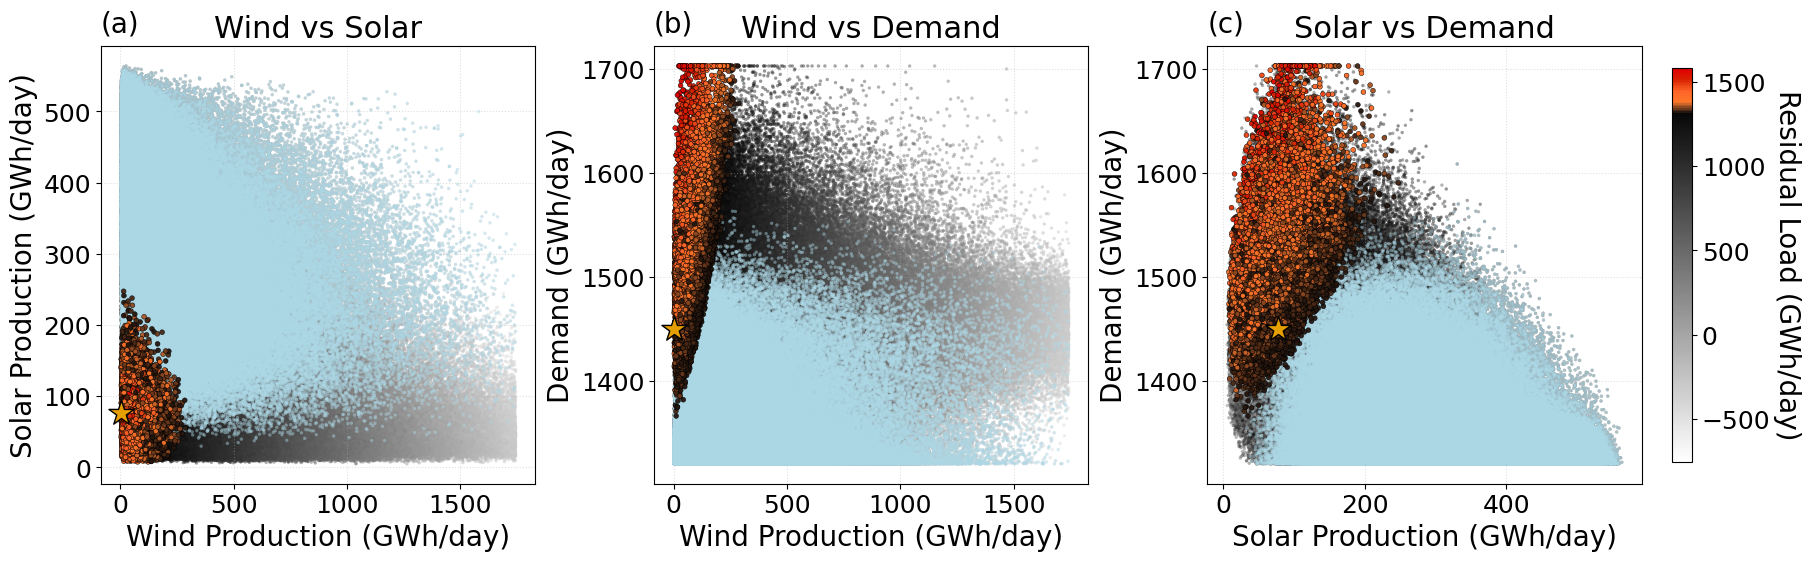

In [13]:


mpl.rcParams.update({
    'font.size': 16+4,
    'axes.titlesize': 18+4,
    'axes.labelsize': 16+4,
    'xtick.labelsize': 14+4,
    'ytick.labelsize': 14+4,
    'legend.fontsize': 16+4,
    'figure.titlesize': 18+4,
})


# -------------- user parameters --------------
marker_all = 6
marker_filt = 12
alpha_all = 0.45
alpha_filt = 0.95
figsize = (18, 5.5)

# base colormaps you want to combine
cmap_low = plt.cm.binary        # used for the lower/majority range
# cmap_high = plt.cm.gist_heat_r  # used only for the top portion
# orig = plt.cm.gist_heat_r
# colors = orig(np.linspace(0.0, 1.0, 256))
# # replace the darkest color with a dark red (hex chosen here)
# colors[-1] = mcolors.to_rgba("#bb0000")
# cmap_high = mcolors.LinearSegmentedColormap.from_list('gist_heat_r_darkred_end', colors)

# cmap_high = plt.cm.get_cmap('YlOrRd')  # less custom but also avoids black
cmap_high = mcolors.LinearSegmentedColormap.from_list(
    'yellow_orange_darkred',
    ["#fe8f4f", "#fe7729", "#fe6529", "#d92101", "#df0000"]  # light yellow -> orange -> dark red
)


# fraction of the colormap to reserve for cmap_high (top of the scale)
upper_frac = 0.05   # 0.05 -> top 5% of colors come from cmap_high

# number of discrete colors in combined map (higher -> smoother)
ncolors = 256

# seam blending width in colors (to smooth transition); small integer like 6..12
blend = 8
# ----------------------------------------------

# ------------------ Replace previous colormap-building with this ------------------
# threshold in original Residual_load units (set to the value you want)
threshold = 1319.1588066525014
# 1398.1161147066591  # <- change this to your desired threshold

# ensure vmin/vmax are available (if not, derive from combined df + df_filtered)
if 'vmin' not in globals() or 'vmax' not in globals():
    c_pool = np.concatenate([
        df['Residual_load'].to_numpy().ravel(),
        df_filtered['Residual_load'].to_numpy().ravel()
    ])
    c_pool = c_pool[np.isfinite(c_pool)]
    if c_pool.size == 0:
        raise RuntimeError("No finite Residual_load values found in df / df_filtered.")
    vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# compute upper_frac from threshold relative to the vmin..vmax range
# if threshold >= vmax -> upper_frac = 0 (no high-colormap)
# if threshold <= vmin -> upper_frac = 1 (all high-colormap)
if vmax <= vmin:
    upper_frac = 0.5  # fallback if degenerate range
else:
    upper_frac = (vmax - threshold) / (vmax - vmin)
    upper_frac = float(np.clip(upper_frac, 0.0, 1.0))

# --- optional alternative: compute fraction based on empirical proportion of points above threshold
# uncomment to use empirical fraction (may be preferable if distribution is skewed)
# c_pool_vals = c_pool  # from above
# upper_frac = np.mean(c_pool_vals >= threshold)

# convert fraction to discrete color counts
n_high = max(2, int(round(upper_frac * ncolors)))
n_low = max(2, ncolors - n_high)
# ensure exact total
if n_low + n_high != ncolors:
    n_low = ncolors - n_high

# sample the two colormaps
colors_low = cmap_low(np.linspace(0.0, 1.0, n_low))
colors_high = cmap_high(np.linspace(0.0, 1.0, n_high))

# create a blended seam to avoid a hard cut (uses `blend` from your config)
if blend > 0:
    b = min(blend, n_low - 1, n_high - 1)
    if b > 0:
        seam_low = colors_low[-b:]
        seam_high = colors_high[:b]
        blended = np.array([ (1 - t) * sl + t * sh for t, sl, sh in zip(np.linspace(0,1,b), seam_low, seam_high) ])
        colors = np.vstack([colors_low[:-b], blended, colors_high[b:]])
    else:
        colors = np.vstack([colors_low, colors_high])
else:
    colors = np.vstack([colors_low, colors_high])

# final combined colormap
combined_cmap = mcolors.LinearSegmentedColormap.from_list("combined_top_threshold", colors)
# -----------------------------------------------------------------------------------


# plotting pairs
pairs = [
    ('wind_total', 'solar_prod', 'Wind Production (GWh/day)', 'Solar Production (GWh/day)', 'Wind vs Solar'),
    ('wind_total', 'demand', 'Wind Production (GWh/day)', 'Demand (GWh/day)', 'Wind vs Demand'),
    ('solar_prod', 'demand', 'Solar Production (GWh/day)', 'Demand (GWh/day)', 'Solar vs Demand'),
]

# determine shared vmin/vmax from both dataframes (no scaling)
c_pool = np.concatenate([
    df['Residual_load'].to_numpy().ravel(),
    df_winter['Residual_load'].to_numpy().ravel(),
    df_filtered['Residual_load'].to_numpy().ravel()
])
c_pool = c_pool[np.isfinite(c_pool)]
if c_pool.size == 0:
    raise RuntimeError("No finite Residual_load values in df / df_filtered.")
vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# create figure and axes
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=False)

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, pairs):
    # background: df
    x_all = df[xcol].to_numpy()
    y_all = df[ycol].to_numpy()
    c_all = df['Residual_load'].to_numpy()
    mask_all = np.isfinite(x_all) & np.isfinite(y_all) & np.isfinite(c_all)
    sc_all = ax.scatter(
        x_all[mask_all], y_all[mask_all],
        c=c_all[mask_all],
        cmap=combined_cmap,
        s=marker_all,
        alpha=alpha_all,
        vmin=vmin, vmax=vmax,
        edgecolors='none', zorder=1
    )
    
    # background: df_winter
    x_w = df_summer[xcol].to_numpy()
    y_w = df_summer[ycol].to_numpy()
    c_w = df_summer['Residual_load'].to_numpy()
    mask_w = np.isfinite(x_w) & np.isfinite(y_w) & np.isfinite(c_w)
    sc_w = ax.scatter(
        x_w[mask_w], y_w[mask_w],
        c=c_w[mask_w],
        cmap=mcolors.LinearSegmentedColormap.from_list('light_blue', ["#add8e6", "#add8e6"]),
        s=marker_all,
        alpha=alpha_all,
        vmin=vmin, vmax=vmax,
        edgecolors='none', zorder=2
    )
    
    # foreground: df_filtered
    x_f = df_filtered[xcol].to_numpy()
    y_f = df_filtered[ycol].to_numpy()
    c_f = df_filtered['Residual_load'].to_numpy()
    mask_f = np.isfinite(x_f) & np.isfinite(y_f) & np.isfinite(c_f)
    sc_f = ax.scatter(
        x_f[mask_f], y_f[mask_f],
        c=c_f[mask_f],
        cmap=combined_cmap,
        s=marker_filt,
        alpha=alpha_filt,
        vmin=vmin, vmax=vmax,
        edgecolors='black', linewidths=0.35, zorder=3
    )
    # ax.set_xlim(min(df['solar_prod'].min(), df['wind_total'].min(), df['demand'].min()), max(df['solar_prod'].max(), df['wind_total'].max(), df['demand'].max()))
    # ax.set_ylim(min(df['solar_prod'].min(), df['wind_total'].min(), df['demand'].min()), max(df['solar_prod'].max(), df['wind_total'].max(), df['demand'].max()))

    # Set star marker at df_filtered_CS
    x_cs = df_filtered_CS[xcol].to_numpy()
    y_cs = df_filtered_CS[ycol].to_numpy()
    # c_cs = df_filtered_CS['Residual_load'].to_numpy()
    ax.scatter(
        x_cs, y_cs,
        c="#E69F00",
        cmap=combined_cmap,
        s=marker_filt * 30,
        alpha=1.0,
        vmin=vmin, vmax=vmax,
        edgecolors='black', linewidths=1.0,
        marker='*',
        zorder=4
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.4)

    # # simple legend for roles (not color)
    # legend_elements = [
    #     Line2D([0], [0], marker='o', color='w', label='All days',
    #            markerfacecolor='gray', markersize=7, alpha=alpha_all),
    #     Line2D([0], [0], marker='o', color='w', label='Filtered / VRES',
    #            markerfacecolor='gray', markeredgecolor='k', markersize=10, alpha=alpha_filt)
    # ]
    # ax.legend(handles=legend_elements, loc='upper right')

# left-aligned, not bold, placed just above each subplot
for i, ax in enumerate(axes):
    label = f'({chr(ord("a") + i)})'
    # y slightly above the axis (1.02); use va='bottom' so text sits above the top edge
    ax.text(0.0, 1.02, label,
            transform=ax.transAxes,
            fontweight='normal',  # not bold
            ha='left',
            va='bottom')

# single shared colorbar (maps numeric RL values to the combined colormap)
mappable = plt.cm.ScalarMappable(cmap=combined_cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label('Residual Load (GWh/day)', rotation=270, labelpad=22)

# Save plot
# plt.savefig('/home/onennecke/Code/Figures/Sctrplt_composition_marker.png', bbox_inches='tight', dpi=300)
# plt.savefig('/home/onennecke/Code/Figures/Sctrplt_composition_poster.png', bbox_inches='tight', dpi=300)

plt.show()


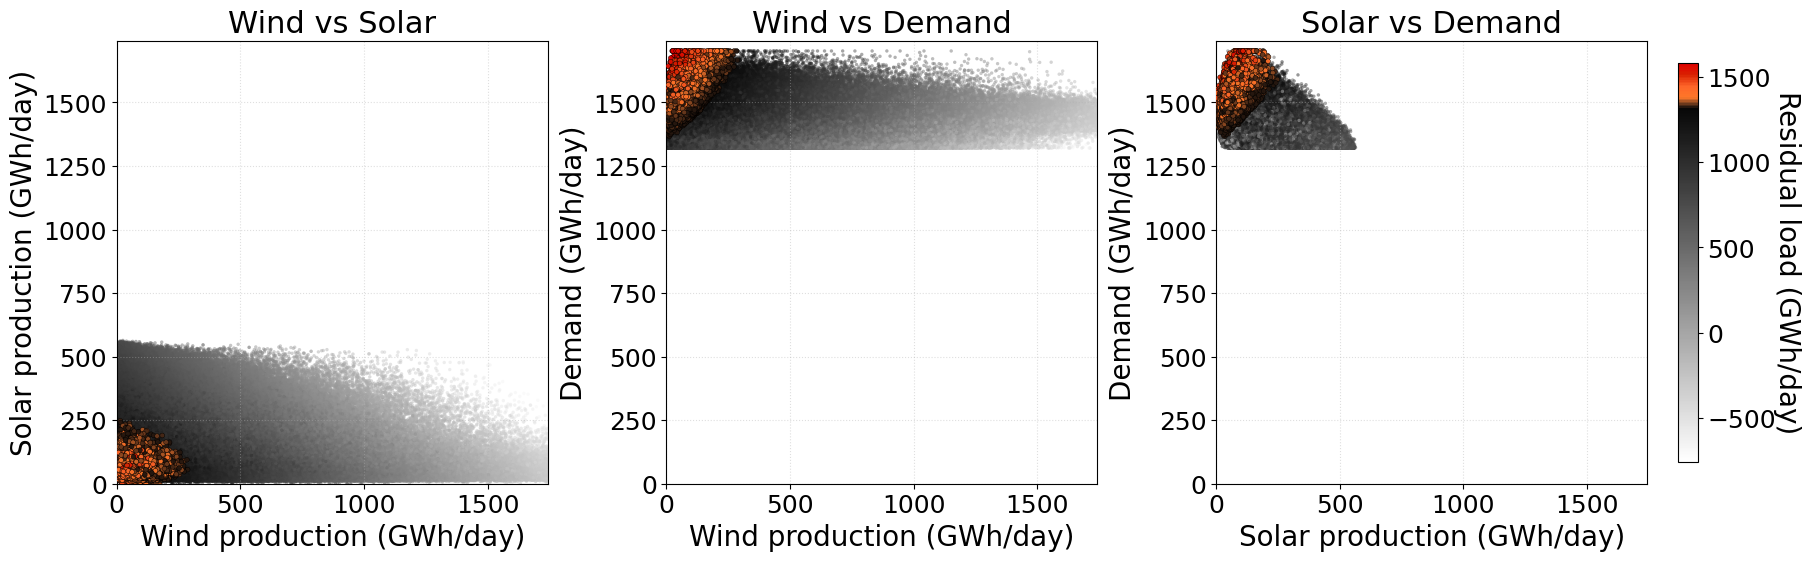

In [33]:
# -------------- user parameters --------------
marker_all = 6
marker_filt = 12
alpha_all = 0.45
alpha_filt = 0.95
figsize = (18, 5.5)

# base colormaps you want to combine
cmap_low = plt.cm.binary        # used for the lower/majority range
# cmap_high = plt.cm.gist_heat_r  # used only for the top portion
# orig = plt.cm.gist_heat_r
# colors = orig(np.linspace(0.0, 1.0, 256))
# # replace the darkest color with a dark red (hex chosen here)
# colors[-1] = mcolors.to_rgba("#bb0000")
# cmap_high = mcolors.LinearSegmentedColormap.from_list('gist_heat_r_darkred_end', colors)

# cmap_high = plt.cm.get_cmap('YlOrRd')  # less custom but also avoids black
cmap_high = mcolors.LinearSegmentedColormap.from_list(
    'yellow_orange_darkred',
    ["#fe8f4f", "#fe7729", "#fe6529", "#d92101", "#df0000"]  # light yellow -> orange -> dark red
)


# fraction of the colormap to reserve for cmap_high (top of the scale)
upper_frac = 0.05   # 0.05 -> top 5% of colors come from cmap_high

# number of discrete colors in combined map (higher -> smoother)
ncolors = 256

# seam blending width in colors (to smooth transition); small integer like 6..12
blend = 8
# ----------------------------------------------

# ------------------ Replace previous colormap-building with this ------------------
# threshold in original Residual_load units (set to the value you want)
threshold = 1319.1588066525014
# 1398.1161147066591  # <- change this to your desired threshold

# ensure vmin/vmax are available (if not, derive from combined df + df_filtered)
if 'vmin' not in globals() or 'vmax' not in globals():
    c_pool = np.concatenate([
        df['Residual_load'].to_numpy().ravel(),
        df_filtered['Residual_load'].to_numpy().ravel()
    ])
    c_pool = c_pool[np.isfinite(c_pool)]
    if c_pool.size == 0:
        raise RuntimeError("No finite Residual_load values found in df / df_filtered.")
    vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# compute upper_frac from threshold relative to the vmin..vmax range
# if threshold >= vmax -> upper_frac = 0 (no high-colormap)
# if threshold <= vmin -> upper_frac = 1 (all high-colormap)
if vmax <= vmin:
    upper_frac = 0.5  # fallback if degenerate range
else:
    upper_frac = (vmax - threshold) / (vmax - vmin)
    upper_frac = float(np.clip(upper_frac, 0.0, 1.0))

# --- optional alternative: compute fraction based on empirical proportion of points above threshold
# uncomment to use empirical fraction (may be preferable if distribution is skewed)
# c_pool_vals = c_pool  # from above
# upper_frac = np.mean(c_pool_vals >= threshold)

# convert fraction to discrete color counts
n_high = max(2, int(round(upper_frac * ncolors)))
n_low = max(2, ncolors - n_high)
# ensure exact total
if n_low + n_high != ncolors:
    n_low = ncolors - n_high

# sample the two colormaps
colors_low = cmap_low(np.linspace(0.0, 1.0, n_low))
colors_high = cmap_high(np.linspace(0.0, 1.0, n_high))

# create a blended seam to avoid a hard cut (uses `blend` from your config)
if blend > 0:
    b = min(blend, n_low - 1, n_high - 1)
    if b > 0:
        seam_low = colors_low[-b:]
        seam_high = colors_high[:b]
        blended = np.array([ (1 - t) * sl + t * sh for t, sl, sh in zip(np.linspace(0,1,b), seam_low, seam_high) ])
        colors = np.vstack([colors_low[:-b], blended, colors_high[b:]])
    else:
        colors = np.vstack([colors_low, colors_high])
else:
    colors = np.vstack([colors_low, colors_high])

# final combined colormap
combined_cmap = mcolors.LinearSegmentedColormap.from_list("combined_top_threshold", colors)
# -----------------------------------------------------------------------------------


# plotting pairs
pairs = [
    ('wind_total', 'solar_prod', 'Wind production (GWh/day)', 'Solar production (GWh/day)', 'Wind vs Solar'),
    ('wind_total', 'demand', 'Wind production (GWh/day)', 'Demand (GWh/day)', 'Wind vs Demand'),
    ('solar_prod', 'demand', 'Solar production (GWh/day)', 'Demand (GWh/day)', 'Solar vs Demand'),
]

# determine shared vmin/vmax from both dataframes (no scaling)
c_pool = np.concatenate([
    df['Residual_load'].to_numpy().ravel(),
    df_filtered['Residual_load'].to_numpy().ravel()
])
c_pool = c_pool[np.isfinite(c_pool)]
if c_pool.size == 0:
    raise RuntimeError("No finite Residual_load values in df / df_filtered.")
vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# create figure and axes
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=False)

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, pairs):
    # background: df
    x_all = df[xcol].to_numpy()
    y_all = df[ycol].to_numpy()
    c_all = df['Residual_load'].to_numpy()
    mask_all = np.isfinite(x_all) & np.isfinite(y_all) & np.isfinite(c_all)
    sc_all = ax.scatter(
        x_all[mask_all], y_all[mask_all],
        c=c_all[mask_all],
        cmap=combined_cmap,
        s=marker_all,
        alpha=alpha_all,
        vmin=vmin, vmax=vmax,
        edgecolors='none', zorder=1
    )

    # foreground: df_filtered
    x_f = df_filtered[xcol].to_numpy()
    y_f = df_filtered[ycol].to_numpy()
    c_f = df_filtered['Residual_load'].to_numpy()
    mask_f = np.isfinite(x_f) & np.isfinite(y_f) & np.isfinite(c_f)
    sc_f = ax.scatter(
        x_f[mask_f], y_f[mask_f],
        c=c_f[mask_f],
        cmap=combined_cmap,
        s=marker_filt,
        alpha=alpha_filt,
        vmin=vmin, vmax=vmax,
        edgecolors='black', linewidths=0.35, zorder=3
    )
    ax.set_xlim(min(df['solar_prod'].min(), df['wind_total'].min(), df['demand'].min()), max(df['solar_prod'].max(), df['wind_total'].max(), df['demand'].max()))
    ax.set_ylim(min(df['solar_prod'].min(), df['wind_total'].min(), df['demand'].min()), max(df['solar_prod'].max(), df['wind_total'].max(), df['demand'].max()))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.4)

    # # simple legend for roles (not color)
    # legend_elements = [
    #     Line2D([0], [0], marker='o', color='w', label='All days',
    #            markerfacecolor='gray', markersize=7, alpha=alpha_all),
    #     Line2D([0], [0], marker='o', color='w', label='Filtered / VRES',
    #            markerfacecolor='gray', markeredgecolor='k', markersize=10, alpha=alpha_filt)
    # ]
    # ax.legend(handles=legend_elements, loc='upper right')

# single shared colorbar (maps numeric RL values to the combined colormap)
mappable = plt.cm.ScalarMappable(cmap=combined_cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label('Residual load (GWh/day)', rotation=270, labelpad=18)

plt.show()


In [ ]:
df_reverse_filtered

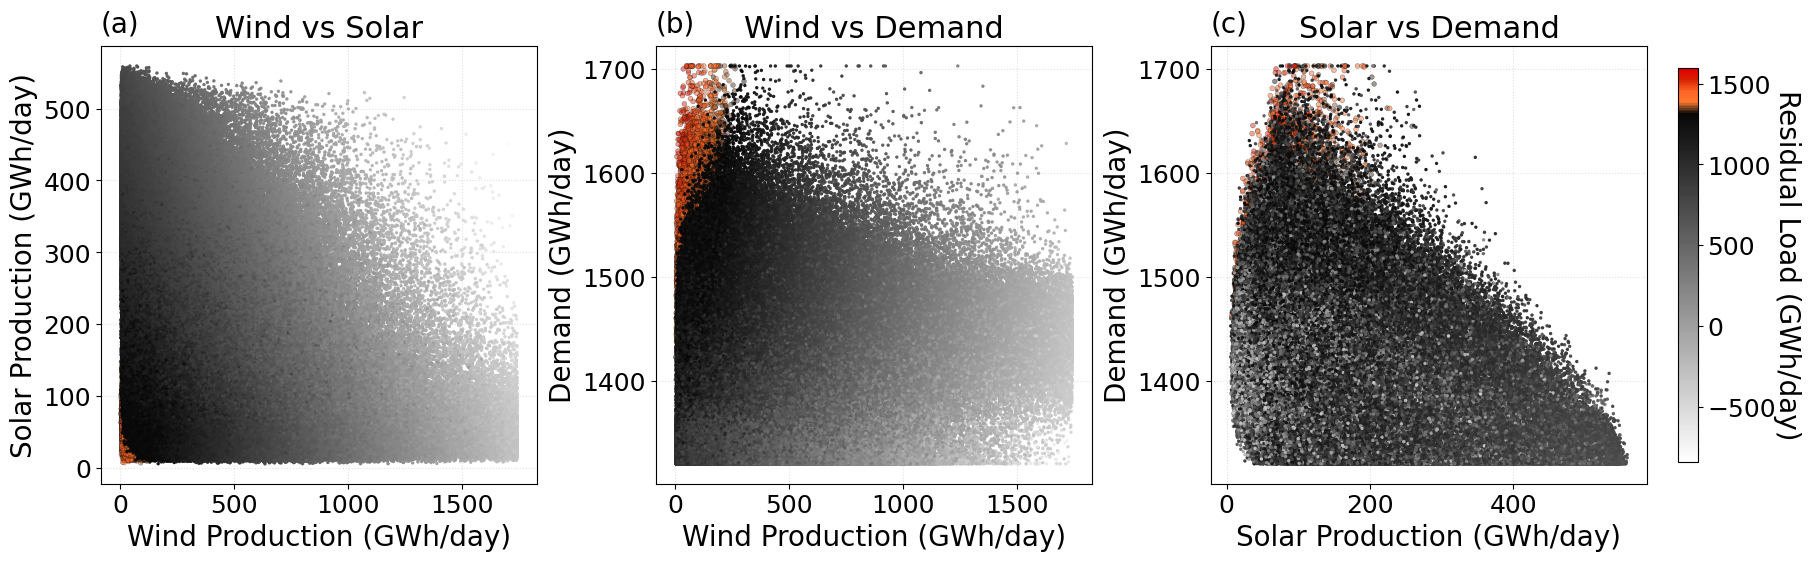

In [29]:

# -------------- user parameters --------------
marker_all = 12
marker_filt = 6
alpha_all = 0.45
alpha_filt = 0.95
figsize = (18, 5.5)

# base colormaps you want to combine
cmap_low = plt.cm.binary        # used for the lower/majority range
# cmap_high = plt.cm.gist_heat_r  # used only for the top portion
# orig = plt.cm.gist_heat_r
# colors = orig(np.linspace(0.0, 1.0, 256))
# # replace the darkest color with a dark red (hex chosen here)
# colors[-1] = mcolors.to_rgba("#bb0000")
# cmap_high = mcolors.LinearSegmentedColormap.from_list('gist_heat_r_darkred_end', colors)

# cmap_high = plt.cm.get_cmap('YlOrRd')  # less custom but also avoids black
cmap_high = mcolors.LinearSegmentedColormap.from_list(
    'yellow_orange_darkred',
    ["#fe8f4f", "#fe7729", "#fe6529", "#d92101", "#df0000"]  # light yellow -> orange -> dark red
)


# fraction of the colormap to reserve for cmap_high (top of the scale)
upper_frac = 0.05   # 0.05 -> top 5% of colors come from cmap_high

# number of discrete colors in combined map (higher -> smoother)
ncolors = 256

# seam blending width in colors (to smooth transition); small integer like 6..12
blend = 8
# ----------------------------------------------

# ------------------ Replace previous colormap-building with this ------------------
# threshold in original Residual_load units (set to the value you want)
threshold = 1319.1588066525014
# 1398.1161147066591  # <- change this to your desired threshold

# ensure vmin/vmax are available (if not, derive from combined df + df_reverse_filtered)
if 'vmin' not in globals() or 'vmax' not in globals():
    c_pool = np.concatenate([
        df_filtered['Residual_load'].to_numpy().ravel(),
        df_reverse_filtered['Residual_load'].to_numpy().ravel()
    ])
    c_pool = c_pool[np.isfinite(c_pool)]
    if c_pool.size == 0:
        raise RuntimeError("No finite Residual_load values found in df / df_reverse_filtered.")
    vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# compute upper_frac from threshold relative to the vmin..vmax range
# if threshold >= vmax -> upper_frac = 0 (no high-colormap)
# if threshold <= vmin -> upper_frac = 1 (all high-colormap)
if vmax <= vmin:
    upper_frac = 0.5  # fallback if degenerate range
else:
    upper_frac = (vmax - threshold) / (vmax - vmin)
    upper_frac = float(np.clip(upper_frac, 0.0, 1.0))

# --- optional alternative: compute fraction based on empirical proportion of points above threshold
# uncomment to use empirical fraction (may be preferable if distribution is skewed)
# c_pool_vals = c_pool  # from above
# upper_frac = np.mean(c_pool_vals >= threshold)

# convert fraction to discrete color counts
n_high = max(2, int(round(upper_frac * ncolors)))
n_low = max(2, ncolors - n_high)
# ensure exact total
if n_low + n_high != ncolors:
    n_low = ncolors - n_high

# sample the two colormaps
colors_low = cmap_low(np.linspace(0.0, 1.0, n_low))
colors_high = cmap_high(np.linspace(0.0, 1.0, n_high))

# create a blended seam to avoid a hard cut (uses `blend` from your config)
if blend > 0:
    b = min(blend, n_low - 1, n_high - 1)
    if b > 0:
        seam_low = colors_low[-b:]
        seam_high = colors_high[:b]
        blended = np.array([ (1 - t) * sl + t * sh for t, sl, sh in zip(np.linspace(0,1,b), seam_low, seam_high) ])
        colors = np.vstack([colors_low[:-b], blended, colors_high[b:]])
    else:
        colors = np.vstack([colors_low, colors_high])
else:
    colors = np.vstack([colors_low, colors_high])

# final combined colormap
combined_cmap = mcolors.LinearSegmentedColormap.from_list("combined_top_threshold", colors)
# -----------------------------------------------------------------------------------


# plotting pairs
pairs = [
    ('wind_total', 'solar_prod', 'Wind Production (GWh/day)', 'Solar Production (GWh/day)', 'Wind vs Solar'),
    ('wind_total', 'demand', 'Wind Production (GWh/day)', 'Demand (GWh/day)', 'Wind vs Demand'),
    ('solar_prod', 'demand', 'Solar Production (GWh/day)', 'Demand (GWh/day)', 'Solar vs Demand'),
]

# determine shared vmin/vmax from both dataframes (no scaling)
c_pool = np.concatenate([
    df_filtered['Residual_load'].to_numpy().ravel(),
    df_reverse_filtered['Residual_load'].to_numpy().ravel()
])
c_pool = c_pool[np.isfinite(c_pool)]
if c_pool.size == 0:
    raise RuntimeError("No finite Residual_load values in df / df_reverse_filtered.")
vmin, vmax = np.nanmin(c_pool), np.nanmax(c_pool)

# create figure and axes
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=False)

for ax, (xcol, ycol, xlabel, ylabel, title) in zip(axes, pairs):
    # background: df
    x_all = df_filtered[xcol].to_numpy()
    y_all = df_filtered[ycol].to_numpy()
    c_all = df_filtered['Residual_load'].to_numpy()
    mask_all = np.isfinite(x_all) & np.isfinite(y_all) & np.isfinite(c_all)
    sc_all = ax.scatter(
        x_all[mask_all], y_all[mask_all],
        c=c_all[mask_all],
        cmap=combined_cmap,
        s=marker_all,
        alpha=alpha_all,
        vmin=vmin, vmax=vmax,
        edgecolors='black', linewidths=0.35, zorder=1
    )

    # foreground: df_reverse_filtered
    x_f = df_reverse_filtered[xcol].to_numpy()
    y_f = df_reverse_filtered[ycol].to_numpy()
    c_f = df_reverse_filtered['Residual_load'].to_numpy()
    mask_f = np.isfinite(x_f) & np.isfinite(y_f) & np.isfinite(c_f)
    sc_f = ax.scatter(
        x_f[mask_f], y_f[mask_f],
        c=c_f[mask_f],
        cmap=combined_cmap,
        s=marker_filt,
        alpha=alpha_filt,
        vmin=vmin, vmax=vmax,
        edgecolors='none', zorder=3
    )
    # ax.set_xlim(min(df_filtered['solar_prod'].min(), df_filtered['wind_total'].min(), df_filtered['demand'].min()), max(df_filtered['solar_prod'].max(), df_filtered['wind_total'].max(), df_filtered['demand'].max()))
    # ax.set_ylim(min(df_filtered['solar_prod'].min(), df_filtered['wind_total'].min(), df_filtered['demand'].min()), max(df_filtered['solar_prod'].max(), df_filtered['wind_total'].max(), df_filtered['demand'].max()))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.4)

    # # simple legend for roles (not color)
    # legend_elements = [
    #     Line2D([0], [0], marker='o', color='w', label='All days',
    #            markerfacecolor='gray', markersize=7, alpha=alpha_all),
    #     Line2D([0], [0], marker='o', color='w', label='Filtered / VRES',
    #            markerfacecolor='gray', markeredgecolor='k', markersize=10, alpha=alpha_filt)
    # ]
    # ax.legend(handles=legend_elements, loc='upper right')

# left-aligned, not bold, placed just above each subplot
for i, ax in enumerate(axes):
    label = f'({chr(ord("a") + i)})'
    # y slightly above the axis (1.02); use va='bottom' so text sits above the top edge
    ax.text(0.0, 1.02, label,
            transform=ax.transAxes,
            fontweight='normal',  # not bold
            ha='left',
            va='bottom')

# single shared colorbar (maps numeric RL values to the combined colormap)
mappable = plt.cm.ScalarMappable(cmap=combined_cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label('Residual Load (GWh/day)', rotation=270, labelpad=18)

# Save plot
# plt.savefig('/home/onennecke/Code/Figures/Sctrplt_composition_reverse.png', bbox_inches='tight', dpi=300)

plt.show()


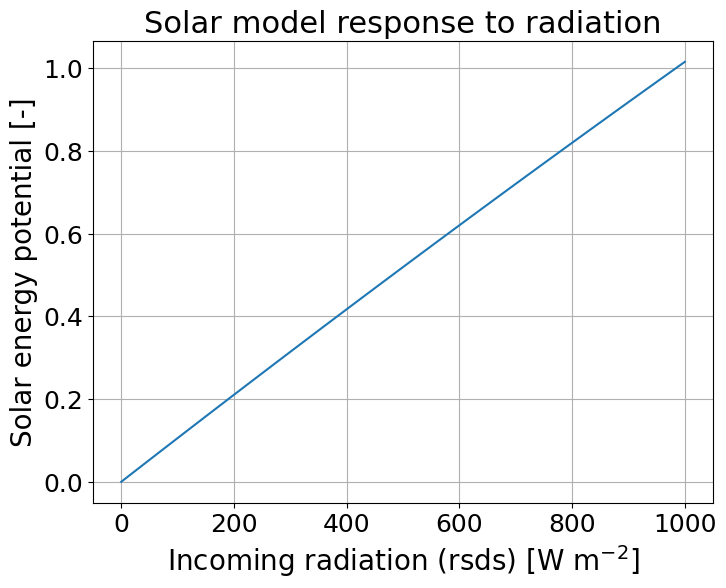

In [40]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import Functions.solar_model_func as solar_model_func
import Functions.config as config

# -----------------------------
# 1. Create simple test dataset
# -----------------------------

# Single location + single day
time = pd.date_range("2020-06-21", periods=1)  # summer solstice
lat = [50]   # 50°N
lon = [10]

# Radiation range to test
rsds_values = np.linspace(0, 1000, 100)  # W/m2

# Fixed meteorology
tas = 20       # 20°C in Kelvin
tasmax = 25    # 25°C in Kelvin
wind = 5.0         # m/s

# Expand dimensions properly
rsds = xr.DataArray(
    rsds_values[:, None, None, None],
    dims=("rsds_level", "time", "lat", "lon"),
    coords={"rsds_level": rsds_values, "time": time, "lat": lat, "lon": lon},
)

tas_da = xr.full_like(rsds, tas)
tasmax_da = xr.full_like(rsds, tasmax)
wind_da = xr.full_like(rsds, wind)

# -----------------------------
# 2. Compute solar potential
# -----------------------------

solar_pot = solar_model_func.compute_solar_energy_potential(
    radiation=rsds,
    temp_at_sfc=tas_da,
    temp_at_sfc_max=tasmax_da,
    surface_wind=wind_da,
    constants=config.pv_constants_unb,
    gamma=config.gamma_unb,
    ref_temp=config.temp_ref_unb,
)

# Remove trivial dims
solar_pot_1d = solar_pot.squeeze()

# -----------------------------
# 3. Plot response curve
# -----------------------------

plt.figure(figsize=(8,6))
plt.plot(rsds_values, solar_pot_1d.values)
plt.xlabel("Incoming radiation (rsds) [W m$^{-2}$]")
plt.ylabel("Solar energy potential [-]")
plt.title("Solar model response to radiation")
plt.grid(True)
plt.show()

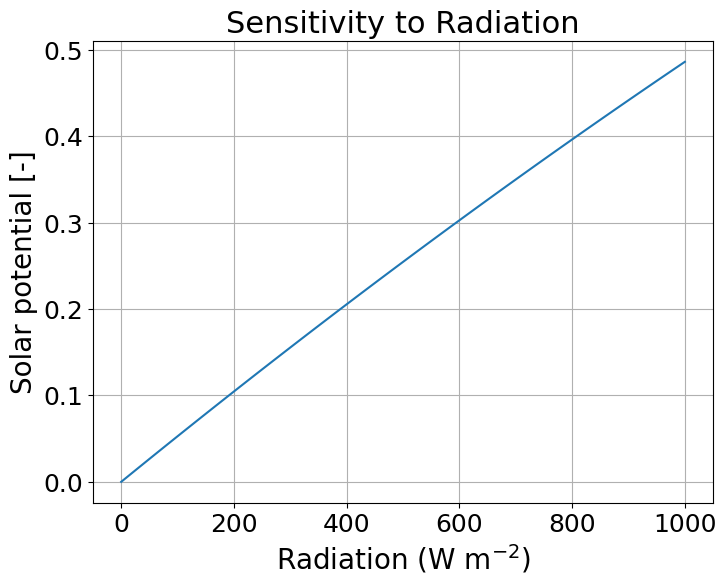

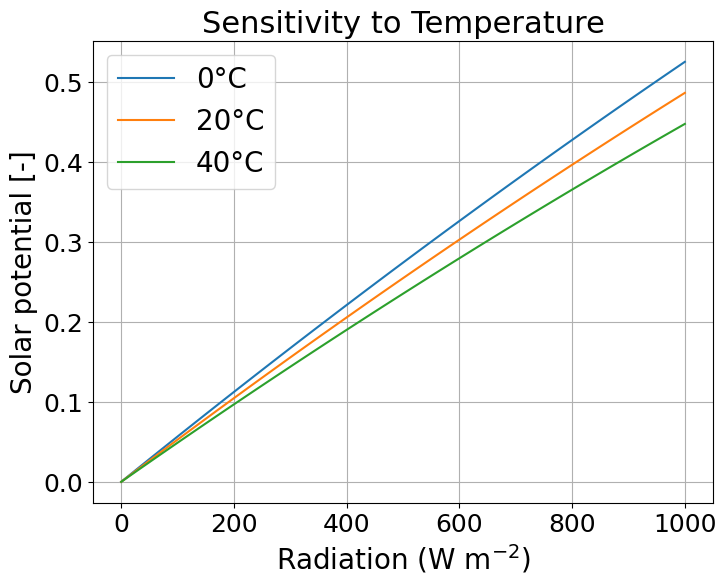

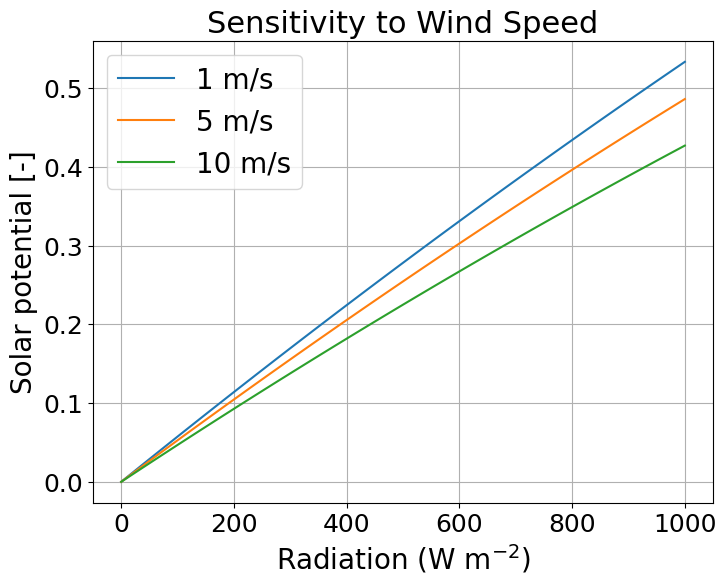

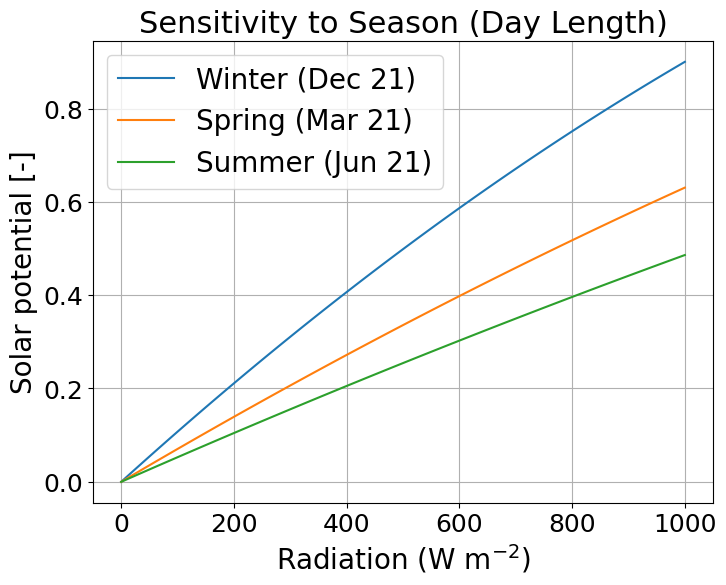

In [41]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import Functions.solar_model_func as solar_model_func
import Functions.config as config

# -----------------------------
# Helper function
# -----------------------------
def compute_potential(rsds, tas, tasmax, wind, date="2020-06-21"):
    time = pd.date_range(date, periods=1)
    lat = [50]
    lon = [10]

    rsds_da = xr.DataArray(
        rsds[:, None, None, None],
        dims=("level", "time", "lat", "lon"),
        coords={"level": rsds, "time": time, "lat": lat, "lon": lon},
    )

    tas_da = xr.full_like(rsds_da, tas)
    tasmax_da = xr.full_like(rsds_da, tasmax)
    wind_da = xr.full_like(rsds_da, wind)

    pot = solar_model_func.compute_solar_energy_potential(
        radiation=rsds_da,
        temp_at_sfc=tas_da,
        temp_at_sfc_max=tasmax_da,
        surface_wind=wind_da,
        constants=config.pv_constants_unb,
        gamma=config.gamma_unb,
        ref_temp=config.temp_ref_unb,
    )

    return pot.squeeze().values


# Base radiation range
rsds_range = np.linspace(0, 1000, 100)


# ==========================================================
# 1️⃣ Radiation sensitivity (baseline)
# ==========================================================

pot_base = compute_potential(
    rsds_range,
    tas=293.15,
    tasmax=298.15,
    wind=5.0,
)

plt.figure(figsize=(8,6))
plt.plot(rsds_range, pot_base)
plt.title("Sensitivity to Radiation")
plt.xlabel("Radiation (W m$^{-2}$)")
plt.ylabel("Solar potential [-]")
plt.grid()
plt.show()


# ==========================================================
# 2️⃣ Temperature sensitivity
# ==========================================================

temps = [273.15, 293.15, 313.15]  # 0°C, 20°C, 40°C

plt.figure(figsize=(8,6))
for T in temps:
    pot = compute_potential(
        rsds_range,
        tas=T,
        tasmax=T+5,
        wind=5.0,
    )
    plt.plot(rsds_range, pot, label=f"{T-273.15:.0f}°C")

plt.title("Sensitivity to Temperature")
plt.xlabel("Radiation (W m$^{-2}$)")
plt.ylabel("Solar potential [-]")
plt.legend()
plt.grid()
plt.show()


# ==========================================================
# 3️⃣ Wind sensitivity
# ==========================================================

winds = [1, 5, 10]

plt.figure(figsize=(8,6))
for w in winds:
    pot = compute_potential(
        rsds_range,
        tas=293.15,
        tasmax=298.15,
        wind=w,
    )
    plt.plot(rsds_range, pot, label=f"{w} m/s")

plt.title("Sensitivity to Wind Speed")
plt.xlabel("Radiation (W m$^{-2}$)")
plt.ylabel("Solar potential [-]")
plt.legend()
plt.grid()
plt.show()


# ==========================================================
# 4️⃣ Seasonal (day-length) sensitivity
# ==========================================================

dates = {
    "Winter (Dec 21)": "2020-12-21",
    "Spring (Mar 21)": "2020-03-21",
    "Summer (Jun 21)": "2020-06-21",
}

plt.figure(figsize=(8,6))
for label, date in dates.items():
    pot = compute_potential(
        rsds_range,
        tas=293.15,
        tasmax=298.15,
        wind=5.0,
        date=date,
    )
    plt.plot(rsds_range, pot, label=label)

plt.title("Sensitivity to Season (Day Length)")
plt.xlabel("Radiation (W m$^{-2}$)")
plt.ylabel("Solar potential [-]")
plt.legend()
plt.grid()
plt.show()